# Credit Risk Modeling - Take-Home Assignment


---

## Objective

Build a production-ready modeling workflow to predict the probability of 12-month loan default.

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis-eda)
3. [Data Preprocessing & Feature Engineering](#3-data-preprocessing--feature-engineering)
4. [Model Training](#4-model-training)
5. [Model Evaluation & Comparison](#5-model-evaluation--comparison)
6. [Model Interpretation](#6-model-interpretation)
7. [Discussion & Next Steps](#7-discussion--next-steps)

---


## 1. Setup & Data Loading


In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', 2000)
pd.set_option('display.max_columns', 2000)
from typing import Dict, Any, Optional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve,
    precision_recall_curve, 
    average_precision_score,
    confusion_matrix, 
    classification_report,
    precision_score,
    recall_score,
    f1_score, 
    average_precision_score
)
from credit_risk_feature_engineering import *
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [7]:
try:
    df = pd.read_csv('../data/credit_risk_data_enhanced.csv')
    # Convert dates
    df['origination_date'] = pd.to_datetime(df['origination_date'])
    print(f"Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print("Error: Data file not found. Please check the path.")

Data Loaded: 50000 rows, 22 columns


## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Data Overview


In [8]:
# Load data
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (50000, 22)

First few rows:


,loan_id,origination_date,vintage,months_on_book,fico_score,income,debt_to_income,num_open_trades,utilization_rate,inquiries_last_6m,loan_amount,term,apr,channel,product_type,employment_length,state,age,days_past_due_current,total_payments_to_date,sample_weight,default_12m
0,LOAN_000000,2024-03-01,202403,6,738,81758,0.0770,7,0.2484,0,31930,36,7.02,Direct,Personal,28,Other,35,15,26162.66,1.0679,0
1,LOAN_000001,2023-05-01,202305,23,818,21891,0.6960,8,0.5129,99,42735,36,11.90,Direct,Auto,5,IL,35,0,41235.13,1.0211,0
2,LOAN_000002,2022-03-01,202203,1,800,82072,0.1439,10,0.5875,1,17564,36,14.01,Partner,Home_Improvement,9,Other,73,0,16494.83,0.8348,0
3,LOAN_000003,2024-07-01,202407,0,657,40335,0.1670,8,0.2927,1,24951,60,10.88,Direct,Debt_Consolidation,14,Other,22,0,23241.67,1.0255,0
4,LOAN_000004,2021-08-01,202108,9,771,11733,0.0337,3,0.1871,0,46939,36,18.10,Partner,Personal,36,NY,54,0,44836.86,1.0370,0


In [9]:
df["origination_date"] = pd.to_datetime(df["origination_date"])

In [ ]:
# check for missing values:

missing_value_rules: Dict[str, int] = {
    "fico_score": 99999,
    "income": -1,
    "inq_last_6m": 99 
}

summary_df = check_missing_values(df, missing_value_rules = missing_value_rules)

In [11]:
summary_df.sort_values(by = 'missing_pct', ascending = False)

,column,missing_count,missing_pct
4,fico_score,2500,5.0
5,income,1500,3.0
0,loan_id,0,0.0
12,apr,0,0.0
20,sample_weight,0,0.0
19,total_payments_to_date,0,0.0
18,days_past_due_current,0,0.0
17,age,0,0.0
16,state,0,0.0
15,employment_length,0,0.0


Default Rate: 2.85%

Class Distribution:
default_12m
0    48574
1     1426
Name: count, dtype: int64


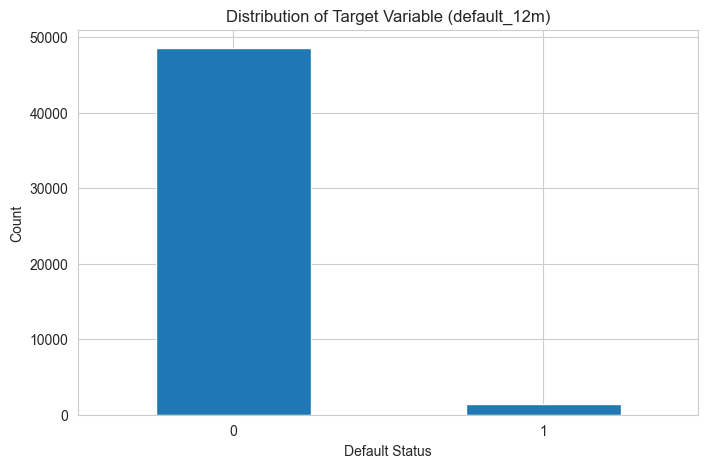

In [ ]:
# Target variable distribution
print(f"Default Rate: {df['default_12m'].mean():.2%}")
print(f"\nClass Distribution:")
print(df['default_12m'].value_counts())

# Visualize
plt.figure(figsize=(8, 5))
df['default_12m'].value_counts().plot(kind='bar')
plt.title('Distribution of Target Variable (default_12m)')
plt.xlabel('Default Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### 2.2 Feature Analysis

TODO: Add your EDA analysis here:
- Distribution plots for numerical features
- Correlation analysis
- Outlier detection
- Relationship between features and target variable
- Analysis of categorical variables


<Axes: title={'center': 'Inquiries Last 6M Distribution'}, xlabel='Inquiries Last 6M', ylabel='Account Count'>

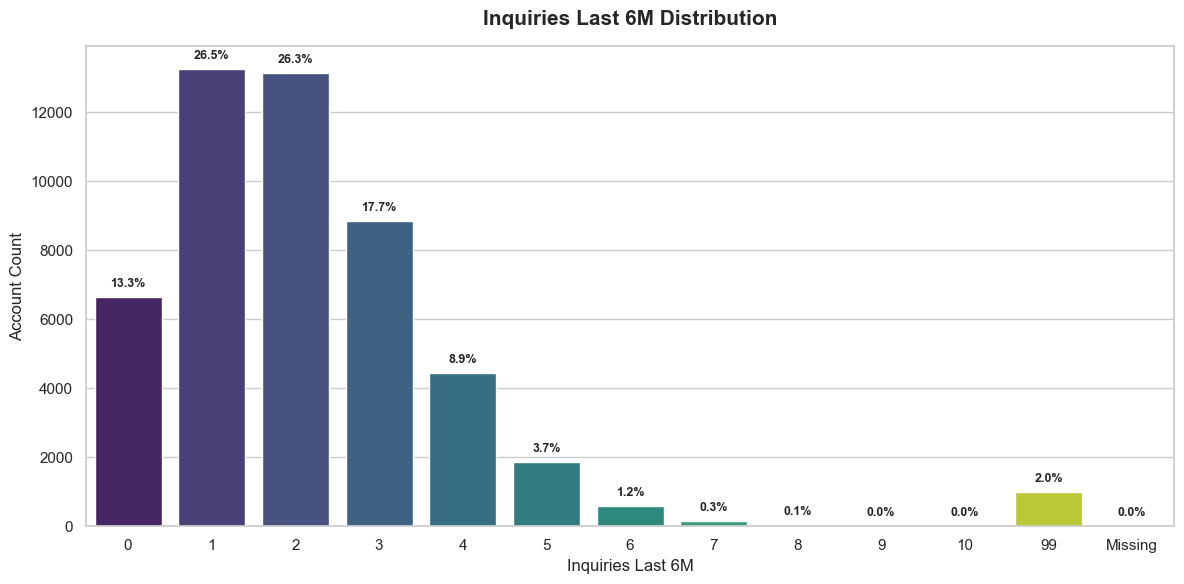

In [87]:
plot_discrete_distribution(df, "inquiries_last_6m", palette="viridis")

<Axes: title={'center': 'Term Distribution'}, xlabel='Term', ylabel='Account Count'>

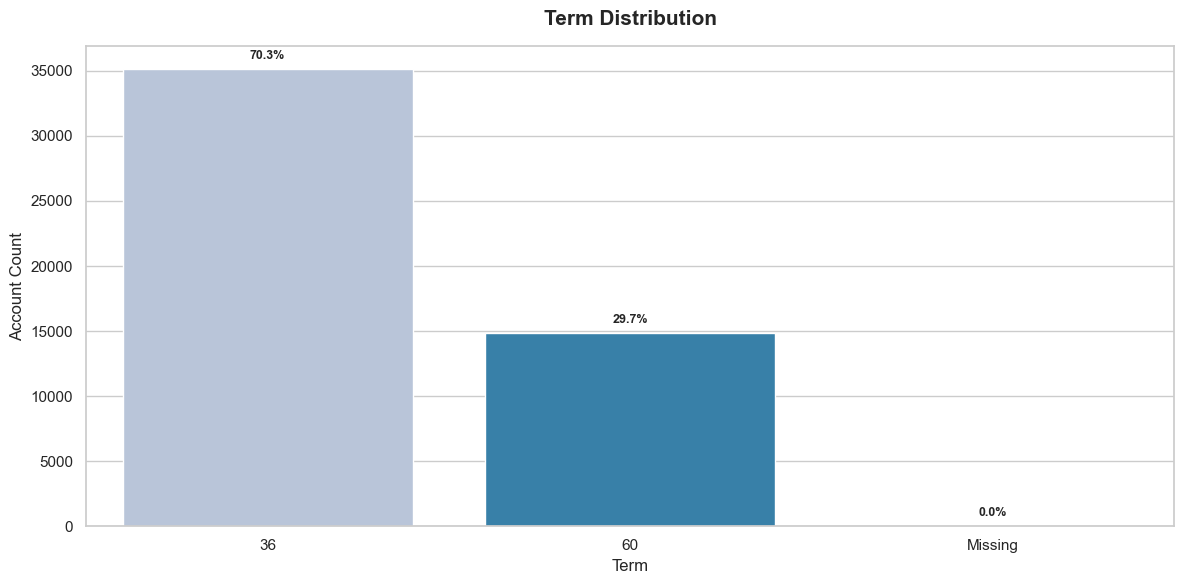

In [88]:
plot_discrete_distribution(df, 'term', palette="PuBu")

<Axes: title={'center': 'Loan Amount Histogram Distribution'}, xlabel='Loan Amount', ylabel='Frequency'>

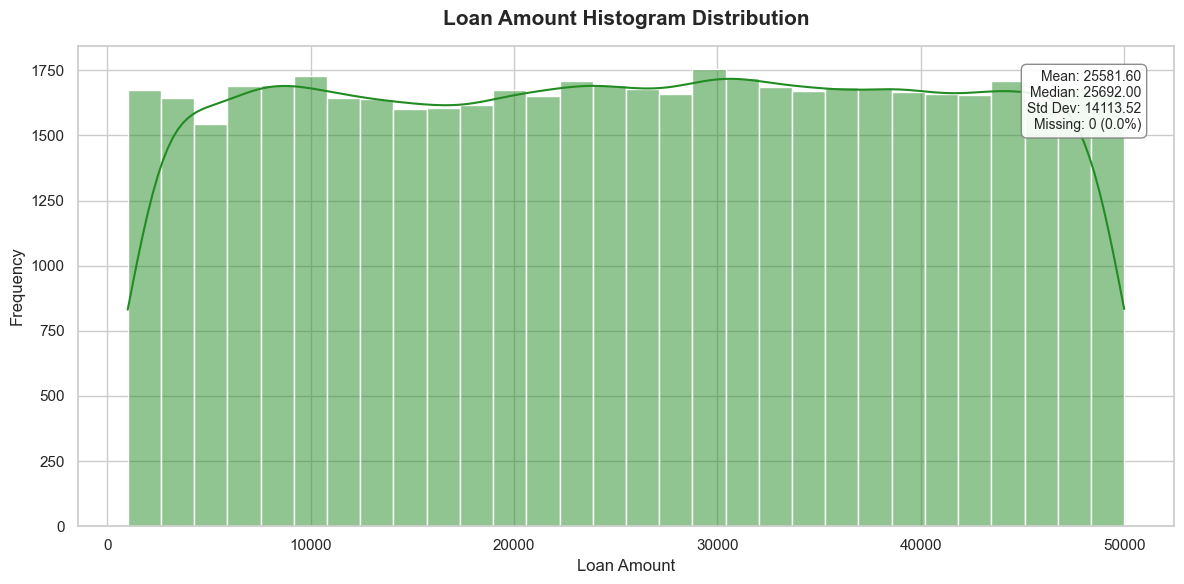

In [89]:
plot_continuous_distribution_hist(df, 'loan_amount', color="forestgreen")

<Axes: title={'center': 'Apr Histogram Distribution'}, xlabel='Apr', ylabel='Frequency'>

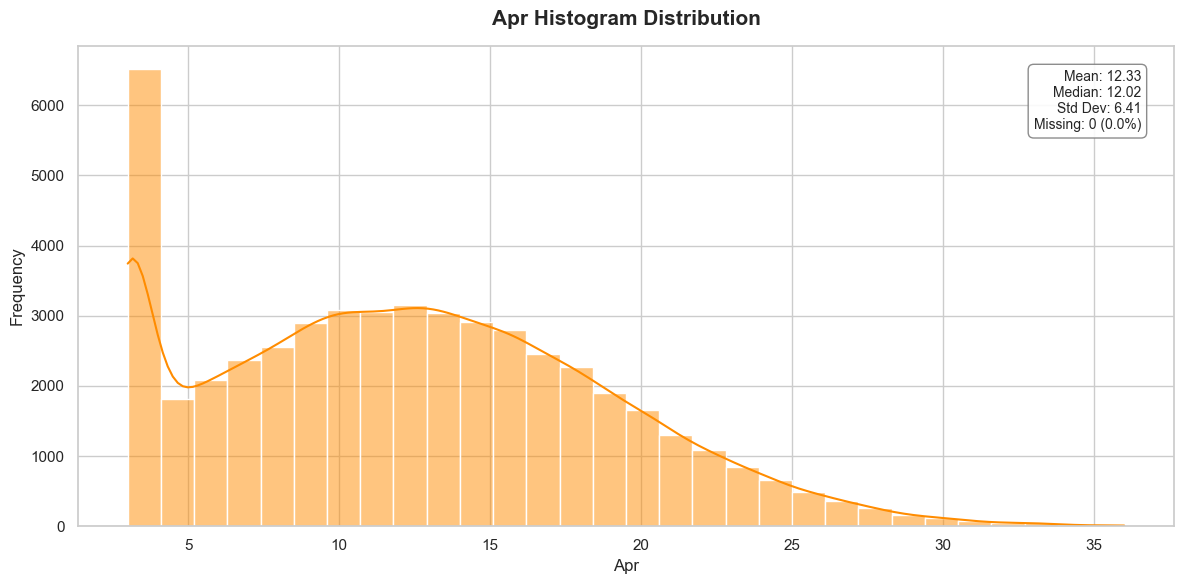

In [90]:
plot_continuous_distribution_hist(df, 'apr', color="darkorange")

<Axes: title={'center': 'Num Open Trades Histogram Distribution'}, xlabel='Num Open Trades', ylabel='Frequency'>

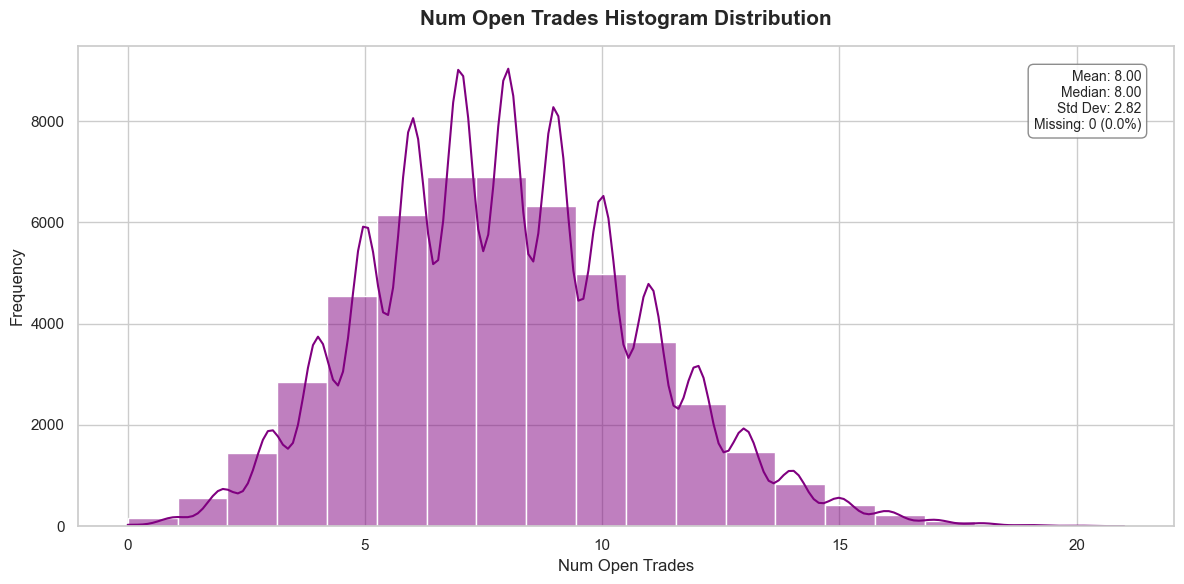

In [91]:
plot_continuous_distribution_hist(df, 'num_open_trades', color="purple", bins=20)

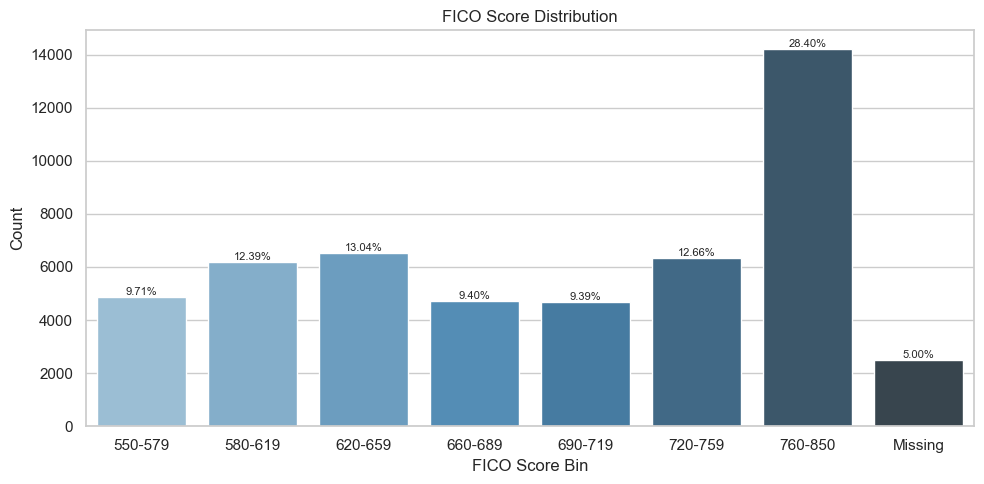

In [21]:
fico_ax = plot_fico_score_distribution(df, fico_col = "fico_score")

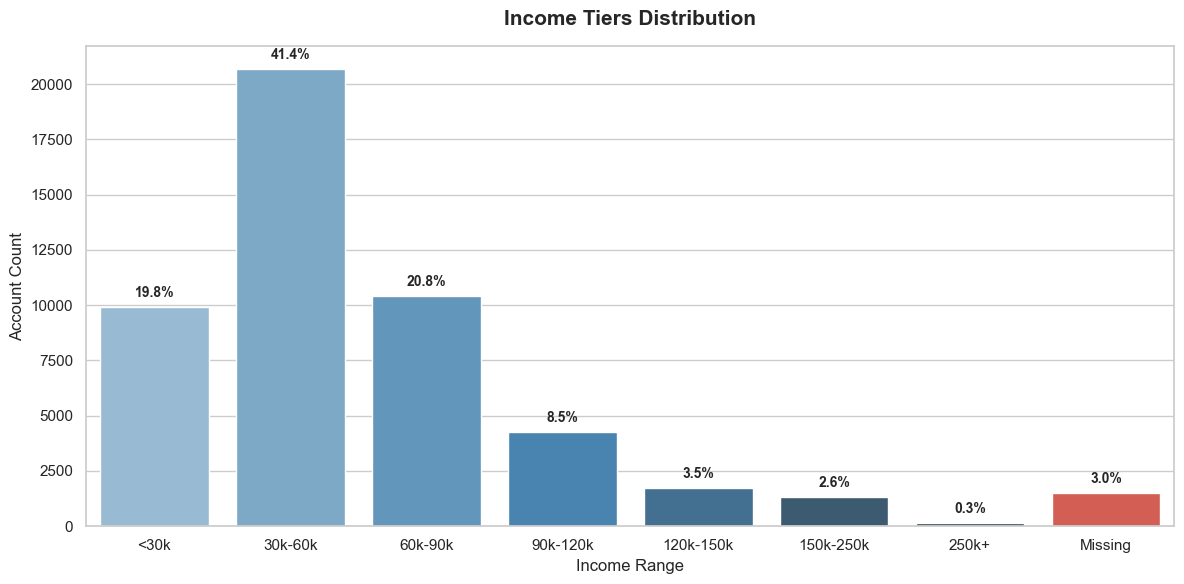

In [ ]:

income_ax = plot_income_distribution(df, income_col='income', title='Income Tiers Distribution')

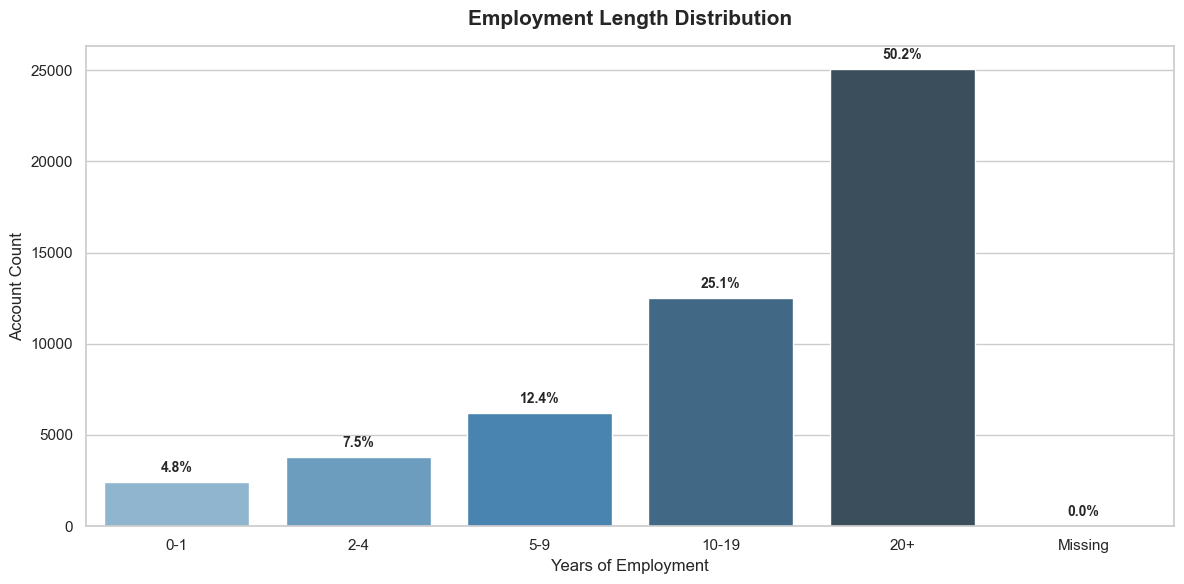

In [ ]:

employment_as = plot_employment_length_distribution(df)

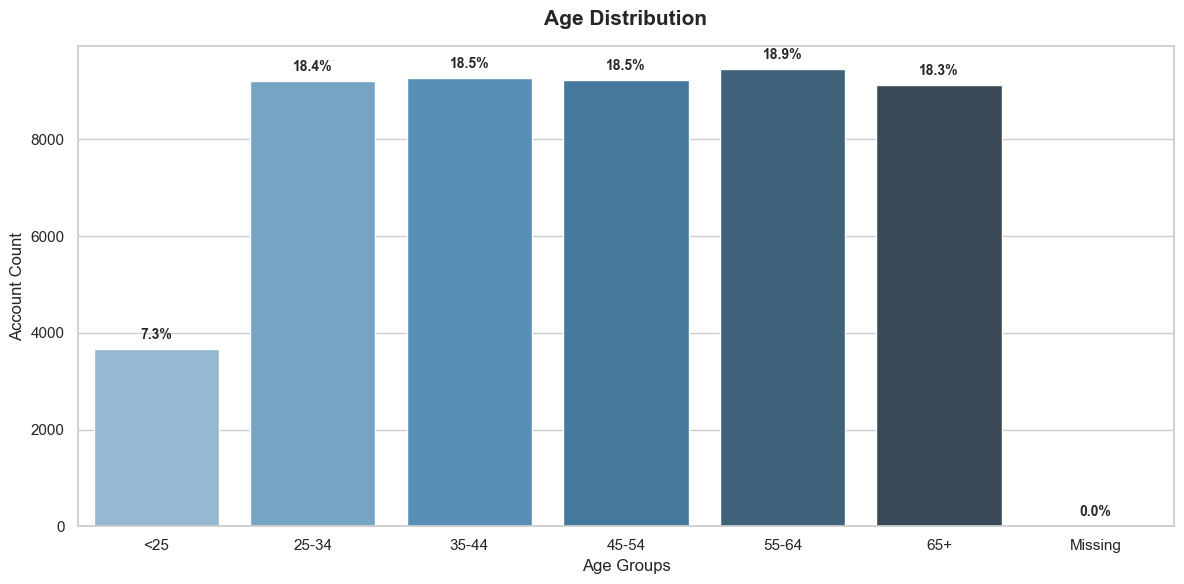

In [ ]:

age_ax = plot_age_distribution(df)

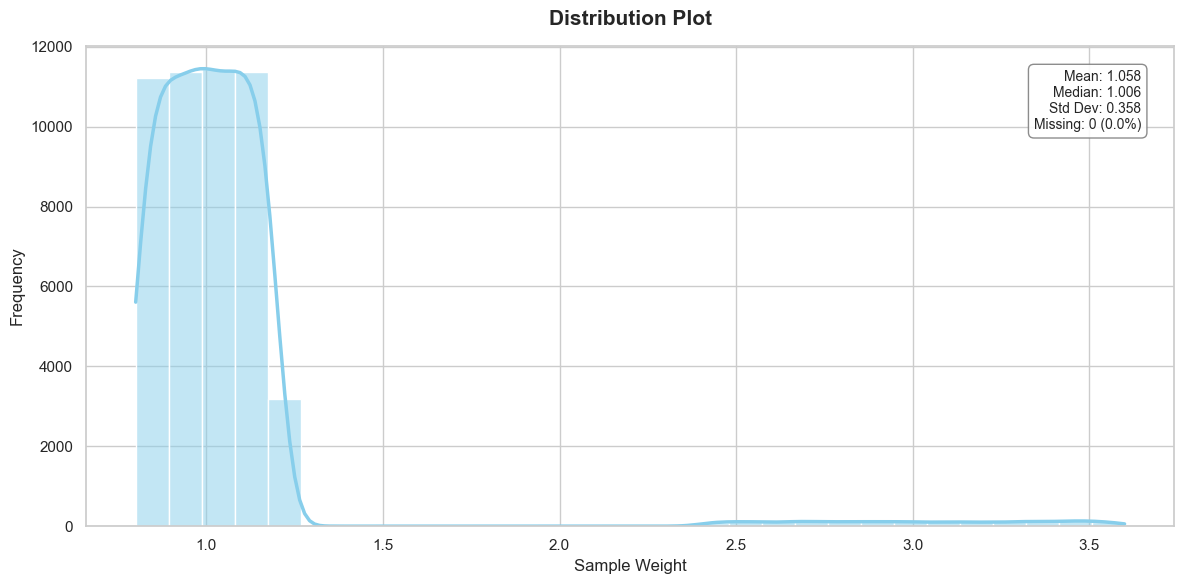

In [95]:
sample_weight_ax = plot_float_distribution_hist(df, "sample_weight")

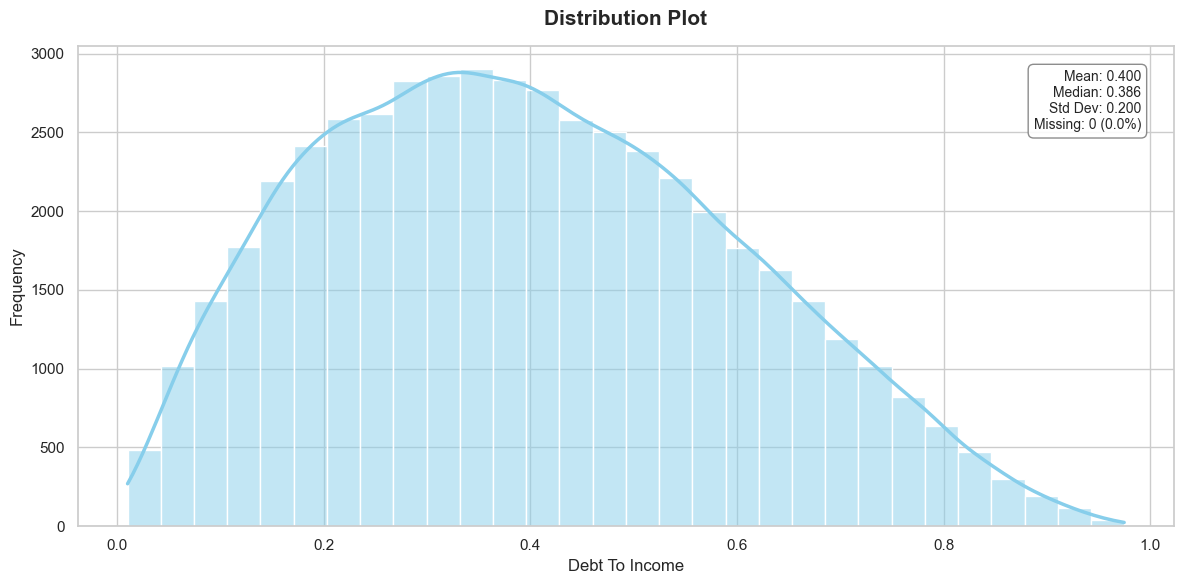

In [96]:
debt_income_ax = plot_float_distribution_hist(df, 'debt_to_income')

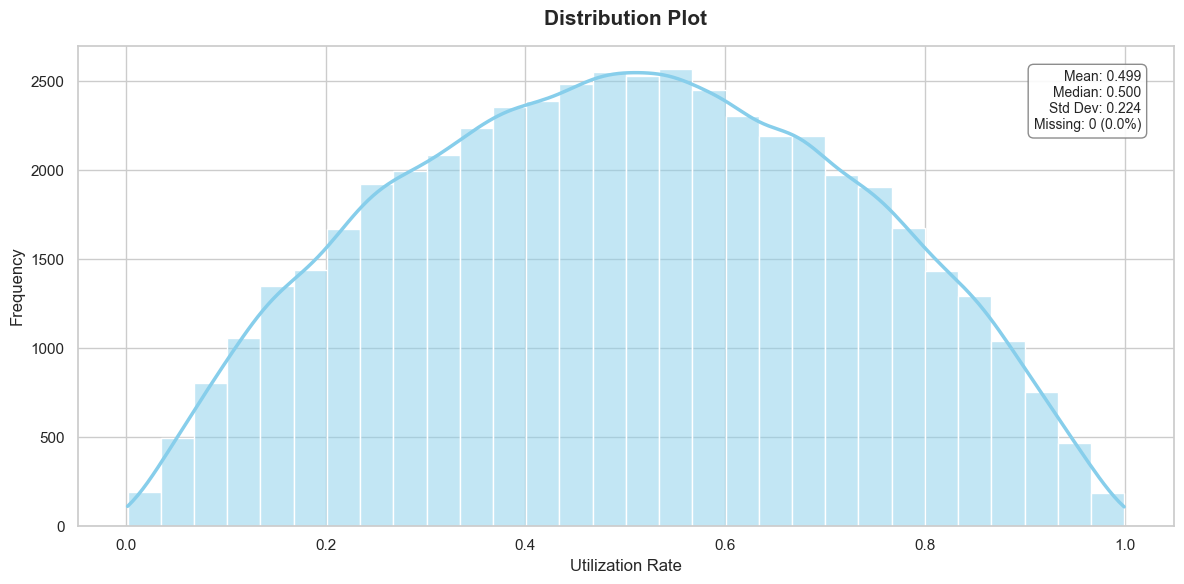

In [97]:
utilization_rate_ax = plot_float_distribution_hist(df, "utilization_rate")

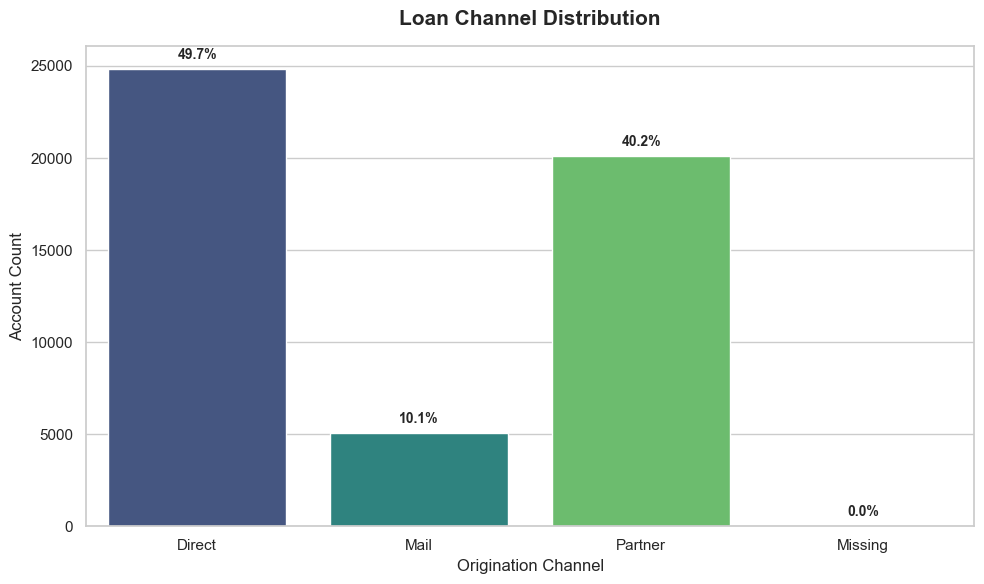

In [ ]:
channel_ax = plot_channel_distribution(df)

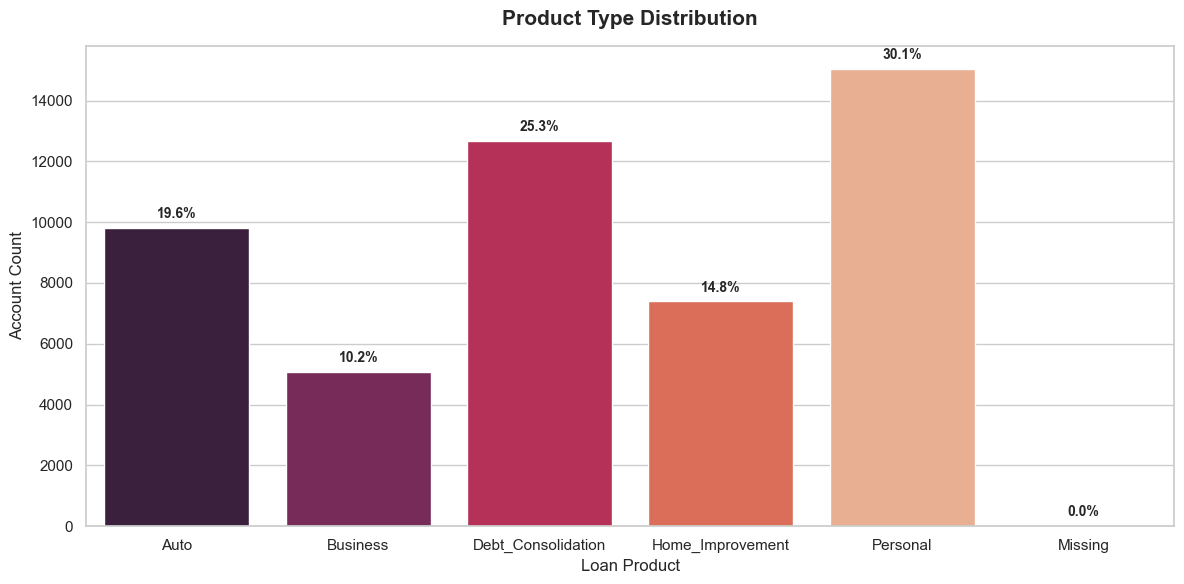

In [ ]:
product_type_ax = plot_product_type_distribution(df)

<Axes: title={'center': 'Distribution of Loans by State'}, xlabel='State', ylabel='Account Count'>

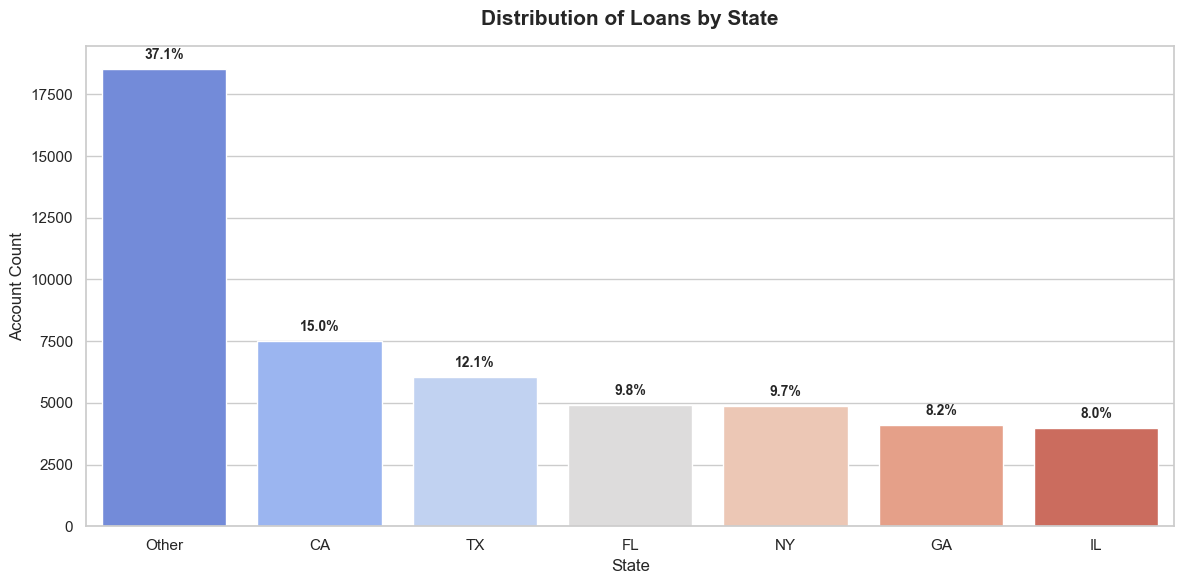

In [ ]:
plot_state_distribution(df)

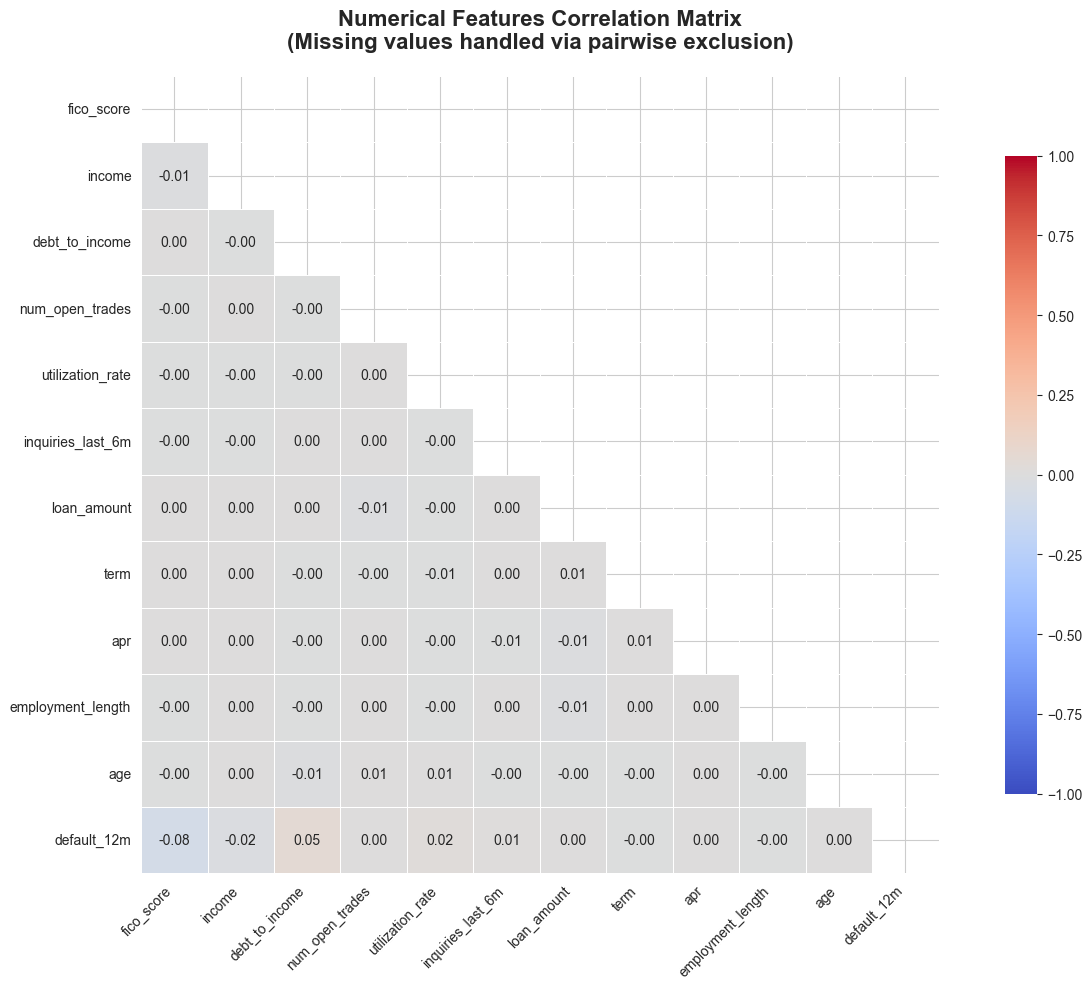


Missing Value Counts (after sentinel replacement):
                   missing_count  missing_pct
fico_score                  2500          5.0
income                      1500          3.0
inquiries_last_6m           1000          2.0


No high correlations found (|r| > 0.7)


Correlation with Target Variable (default_12m):
fico_score          -0.076407
debt_to_income       0.053333
income              -0.023269
utilization_rate     0.018140
inquiries_last_6m    0.011959
term                -0.004767
loan_amount          0.003045
employment_length   -0.002506
age                  0.001775
apr                  0.000952
num_open_trades      0.000839
Name: default_12m, dtype: float64


In [10]:
### 2.3 Correlation Analysis
# Prepare data for correlation (handle missing sentinels but keep as NaN for analysis)
df_corr = df.copy()
df_corr['fico_score'] = df_corr['fico_score'].replace(99999, np.nan)
df_corr['inquiries_last_6m'] = df_corr['inquiries_last_6m'].replace(99, np.nan)
df_corr['income'] = df_corr['income'].replace(-1, np.nan)

# Exclude non-feature columns
to_exclude = [
    'loan_id', 'origination_date', 'vintage', 
    'months_on_book', 'days_past_due_current', 
    'total_payments_to_date', 'sample_weight'  # sample_weight is not a feature
]

# Keep only numerical features
numerical_df = df_corr.drop(columns=[c for c in to_exclude if c in df_corr.columns])
numerical_df = numerical_df.select_dtypes(include=[np.number])

# Calculate correlation matrix (pandas handles NaN by pairwise exclusion)
corr_matrix = numerical_df.corr()

# Plot correlation heatmap with upper triangle mask
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8},
    vmin=-1, vmax=1
)

plt.title("Numerical Features Correlation Matrix\n(Missing values handled via pairwise exclusion)", 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Show missing value counts for context
print("\nMissing Value Counts (after sentinel replacement):")
missing_counts = numerical_df.isna().sum()
missing_pct = (missing_counts / len(numerical_df) * 100).round(2)
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})
print(missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False))

# Identify high correlations (absolute value > 0.7, excluding diagonal)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_val
            })

if high_corr_pairs:
    print("\n\nHigh Correlation Pairs (|r| > 0.7):")
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.sort_values('correlation', key=abs, ascending=False))
else:
    print("\n\nNo high correlations found (|r| > 0.7)")

# Correlation with target variable
target_corr = corr_matrix['default_12m'].drop('default_12m').sort_values(key=abs, ascending=False)
print("\n\nCorrelation with Target Variable (default_12m):")
print(target_corr)

In [ ]:
### 2.4 Outlier Detection
# Select numeric features for outlier detection
numeric_features = ['fico_score', 'income', 'debt_to_income', 'num_open_trades',
                   'utilization_rate', 'inquiries_last_6m', 'loan_amount', 
                   'term', 'apr', 'employment_length', 'age']

# Detect outliers for each numeric feature
outlier_summary = []
for col in numeric_features:
    if col in df.columns:
        outlier_stats = detect_outliers_iqr(df, col)
        outlier_summary.append(outlier_stats)

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values('outlier_pct', ascending=False)

print("Outlier Detection Summary (IQR Method, 1.5x multiplier):")
print("=" * 100)
print(outlier_df[['column', 'valid_count', 'missing_count', 'missing_pct', 
                  'outlier_count', 'outlier_pct', 'min_value', 'max_value']].to_string(index=False))
print("\n")

# Visualize outliers for features with high outlier percentage (>5%)
high_outlier_features = outlier_df[outlier_df['outlier_pct'] > 5]['column'].tolist()

if high_outlier_features:
    print(f"Features with >5% outliers: {', '.join(high_outlier_features)}")
    print("\nBoxplots for high-outlier features:")
    
    n_features = len(high_outlier_features)
    n_cols = 2
    n_rows = (n_features + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(high_outlier_features):
        plot_outlier_boxplot(df, col, figsize=(6, 4))
        plt.show()
else:
    print("No features have >5% outliers.")

Outlier Detection Summary (IQR Method, 1.5x multiplier):
           column  valid_count  missing_count  missing_pct  outlier_count  outlier_pct  min_value   max_value
           income        48500           1500          3.0           2197     4.529897  3947.0000 535593.0000
inquiries_last_6m        49000           1000          2.0            203     0.414286     0.0000     10.0000
  num_open_trades        50000              0          0.0            172     0.344000     0.0000     21.0000
              apr        50000              0          0.0            154     0.308000     3.0000     35.9900
       fico_score        47500           2500          5.0              0     0.000000   550.0000    850.0000
   debt_to_income        50000              0          0.0              0     0.000000     0.0100      0.9747
 utilization_rate        50000              0          0.0              0     0.000000     0.0019      0.9991
      loan_amount        50000              0          0.0     

FEATURE-TARGET RELATIONSHIP ANALYSIS (Including Missing Values)


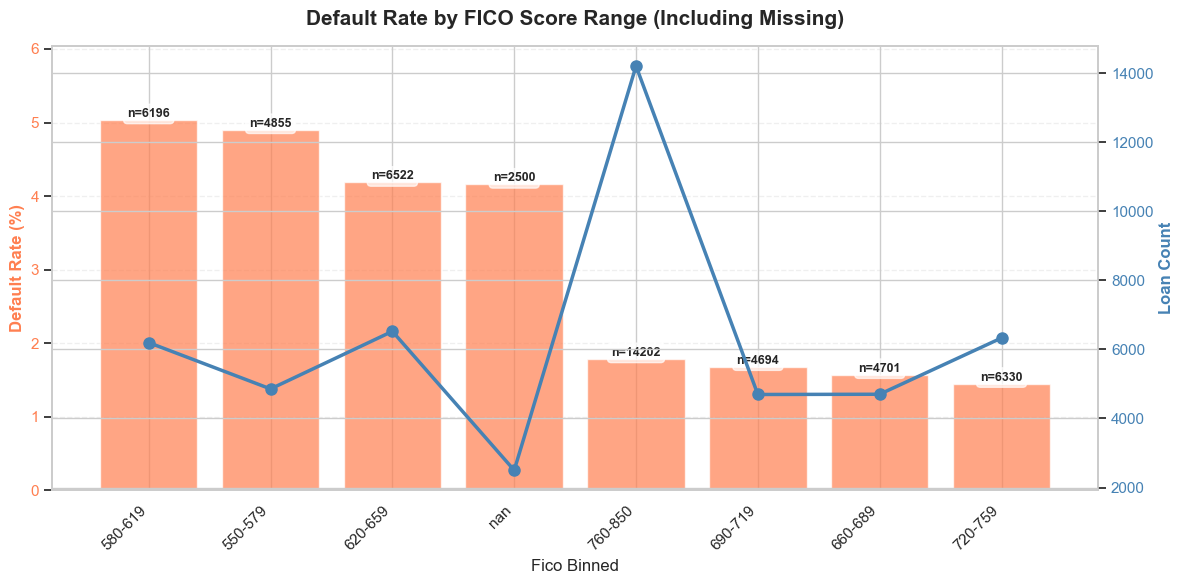

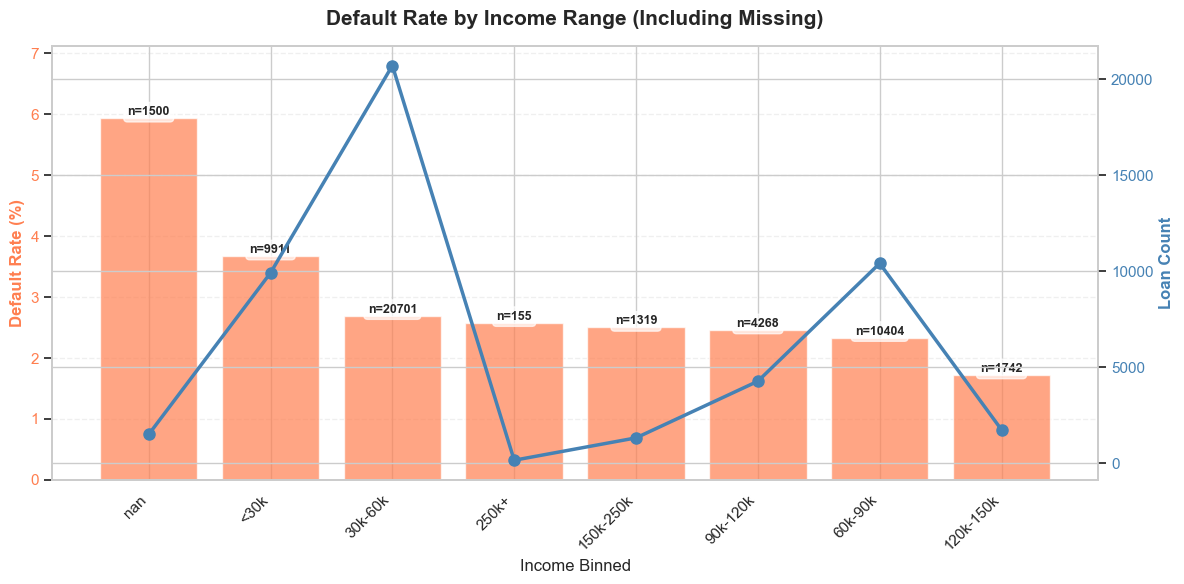

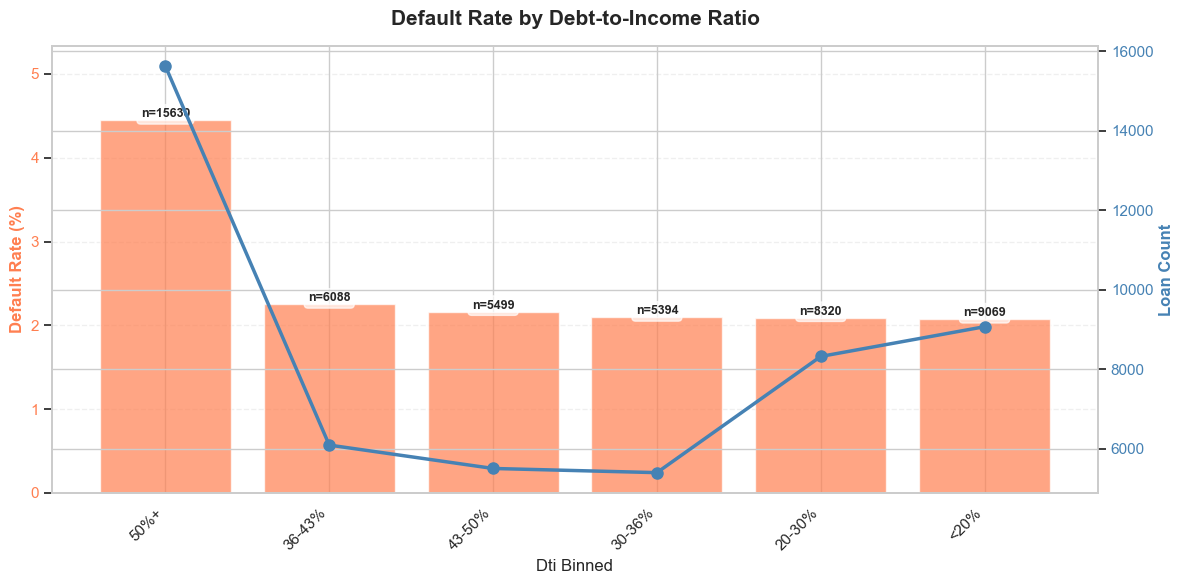

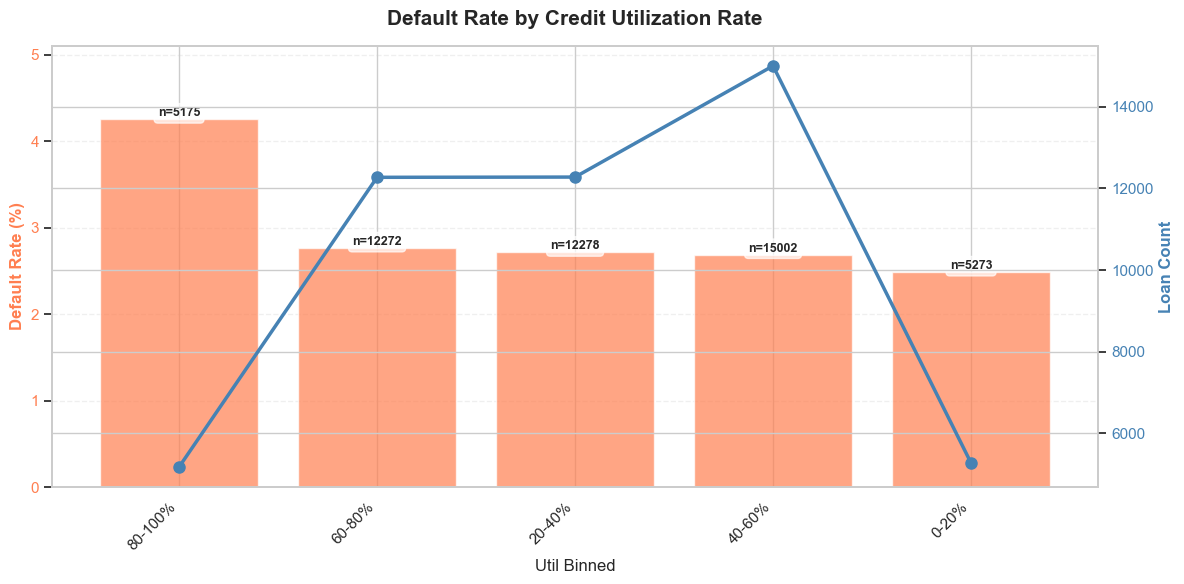

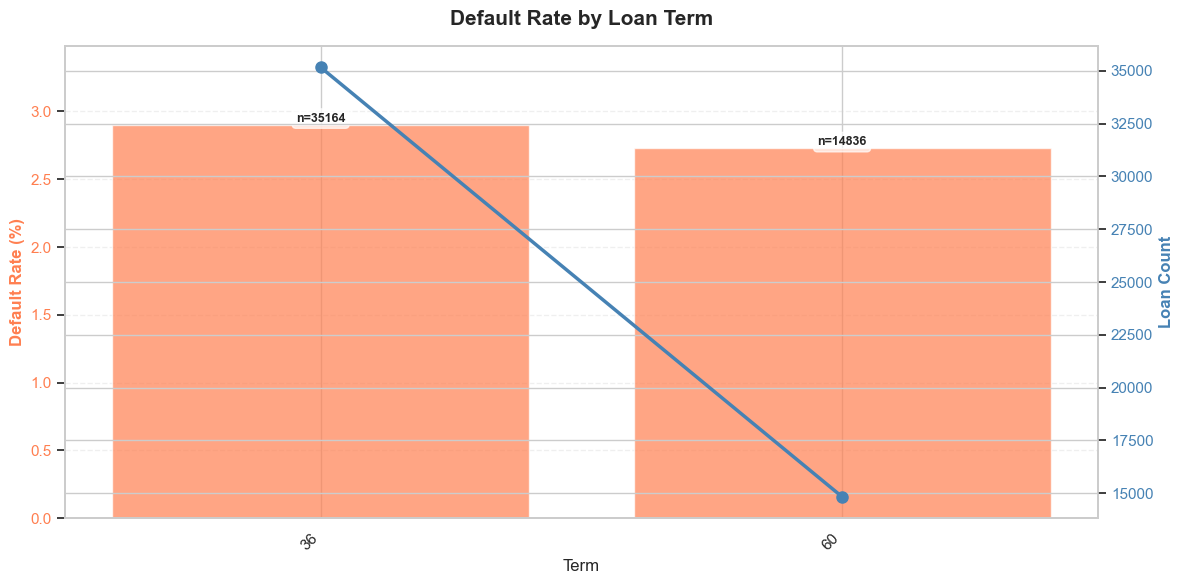

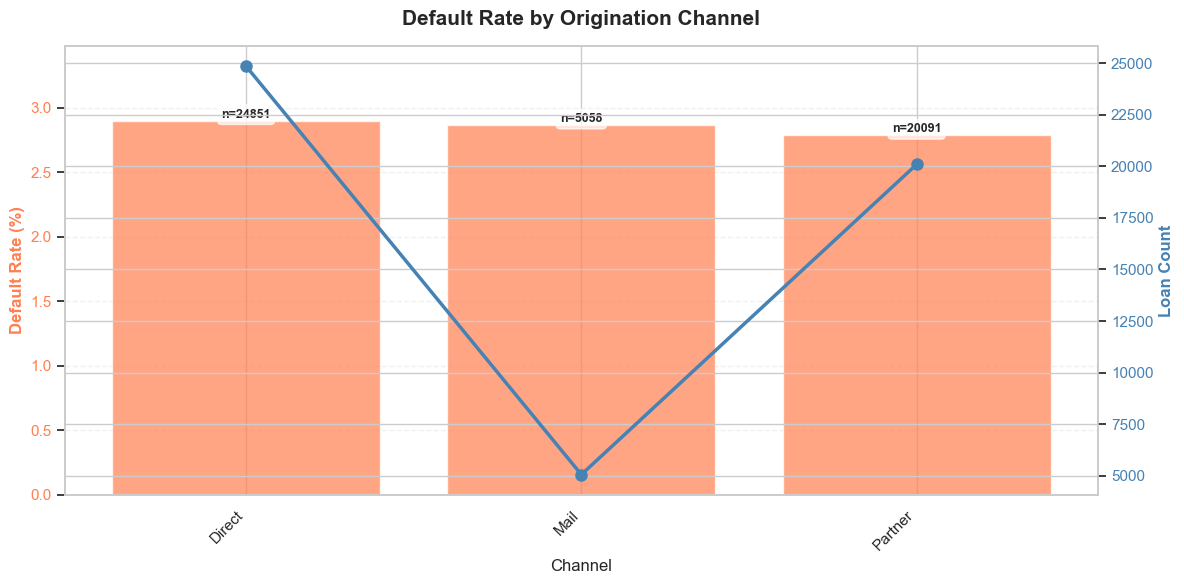

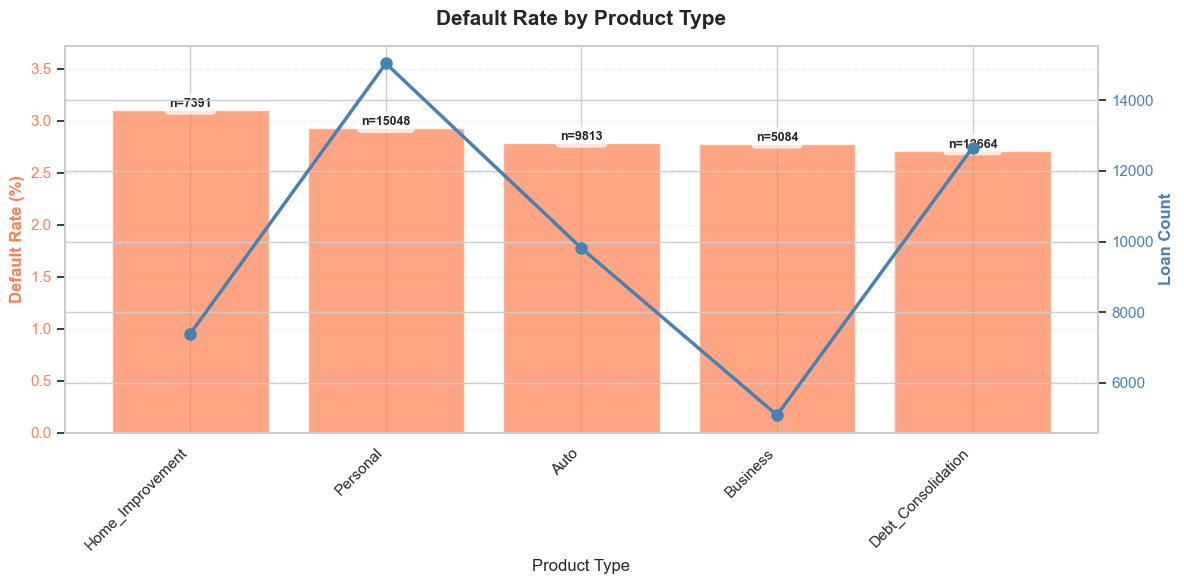

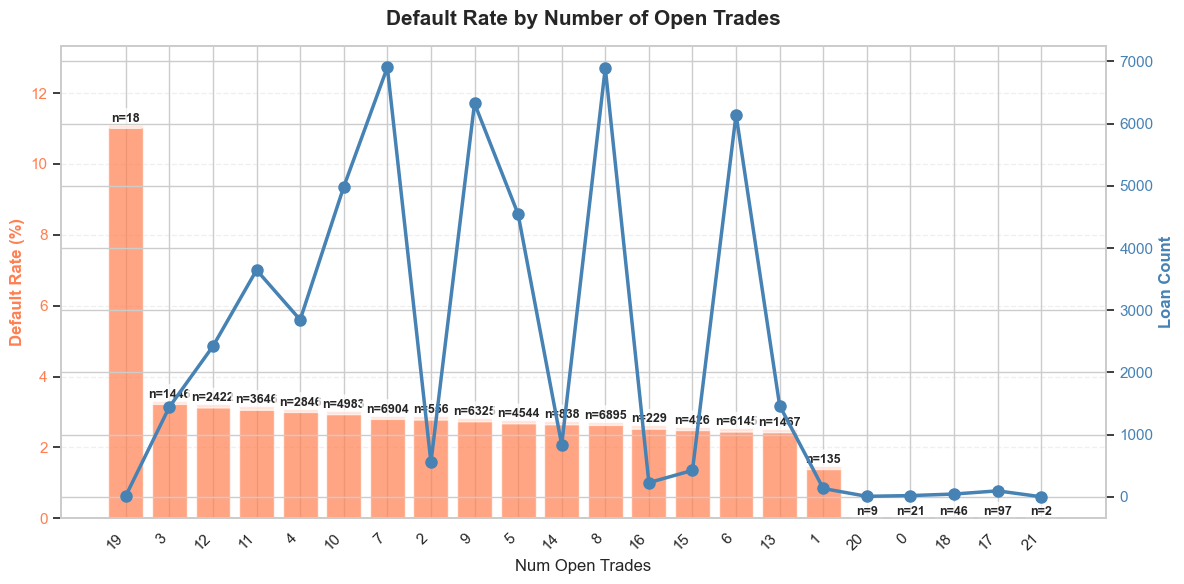

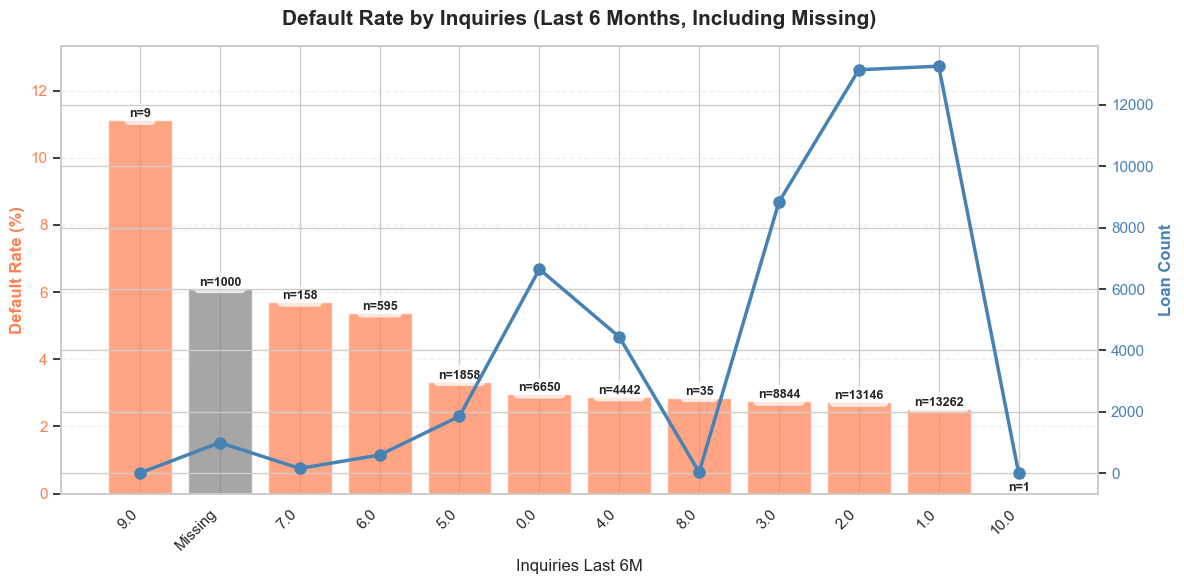


MISSING VALUE ANALYSIS
          feature  missing_count  missing_pct  default_rate_missing  default_rate_nonmissing  difference
       fico_score           2500          5.0                  4.16                     2.78        1.38
           income           1500          3.0                  5.93                     2.76        3.18
inquiries_last_6m           1000          2.0                  6.10                     2.79        3.31

Note: Positive difference means missing values have HIGHER default rate

SUMMARY: Feature Importance (by correlation with target)
fico_score          -0.076407
debt_to_income       0.053333
income              -0.023269
utilization_rate     0.018140
inquiries_last_6m    0.011959
term                -0.004767
loan_amount          0.003045
employment_length   -0.002506
age                  0.001775
apr                  0.000952
num_open_trades      0.000839
Name: default_12m, dtype: float64


In [35]:
# Analyze key numeric features (binned for continuous variables, including missing)
print("=" * 80)
print("FEATURE-TARGET RELATIONSHIP ANALYSIS (Including Missing Values)")
print("=" * 80)

# 1. FICO Score (already binned in your distribution function)
fico_bins = [550, 580, 620, 660, 690, 720, 760, 850]
fico_labels = ["550-579", "580-619", "620-659", "660-689", "690-719", "720-759", "760-850"]
df_fico = df.copy()
df_fico['fico_score'] = df_fico['fico_score'].replace(99999, np.nan)
df_fico['fico_binned'] = pd.cut(df_fico['fico_score'], bins=fico_bins, labels=fico_labels, 
                                right=True, include_lowest=True)
plot_default_rate_by_feature(df_fico, 'fico_binned', title='Default Rate by FICO Score Range (Including Missing)')
plt.show()

# 2. Income (binned)
income_bins = [0, 30000, 60000, 90000, 120000, 150000, 250000, 1000000]
income_labels = ["<30k", "30k-60k", "60k-90k", "90k-120k", "120k-150k", "150k-250k", "250k+"]
df_income = df.copy()
df_income['income'] = df_income['income'].replace(-1, np.nan)
df_income['income_binned'] = pd.cut(df_income['income'], bins=income_bins, labels=income_labels, 
                                   right=False, include_lowest=True)
plot_default_rate_by_feature(df_income, 'income_binned', title='Default Rate by Income Range (Including Missing)')
plt.show()

# 3. Debt-to-Income (binned)
# 3. Debt-to-Income (binned) - Values are in decimal form (0-1)
df_dti = df.copy()

# Standard DTI bins (values are 0-1, so 0.20 = 20%, 0.36 = 36%, etc.)
df_dti['dti_binned'] = pd.cut(df_dti['debt_to_income'], 
                              bins=[0, 0.20, 0.30, 0.36, 0.43, 0.50, 1.0], 
                              labels=['<20%', '20-30%', '30-36%', '36-43%', '43-50%', '50%+'],
                              right=False,
                              include_lowest=True)

plot_default_rate_by_feature(df_dti, 'dti_binned', title='Default Rate by Debt-to-Income Ratio')
plt.show()

# 4. Utilization Rate (binned)
df_util = df.copy()
df_util['util_binned'] = pd.cut(df_util['utilization_rate'], 
                                bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0, 2], 
                                labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '100%+'],
                                right=False)
plot_default_rate_by_feature(df_util, 'util_binned', title='Default Rate by Credit Utilization Rate')
plt.show()

# 5. Discrete/Categorical features
plot_default_rate_by_feature(df, 'term', title='Default Rate by Loan Term')
plt.show()

plot_default_rate_by_feature(df, 'channel', title='Default Rate by Origination Channel')
plt.show()

plot_default_rate_by_feature(df, 'product_type', title='Default Rate by Product Type')
plt.show()

# 6. Count variables (discrete) - these will show Missing if present
plot_default_rate_by_feature(df, 'num_open_trades', title='Default Rate by Number of Open Trades')
plt.show()

# For inquiries, missing is meaningful (sentinel = 99)
plot_default_rate_by_feature(df, 'inquiries_last_6m', title='Default Rate by Inquiries (Last 6 Months, Including Missing)')
plt.show()

# 7. Analyze missing value patterns
print("\n" + "=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

missing_features = ['fico_score', 'income', 'inquiries_last_6m']
missing_summary = []

for col in missing_features:
    df_miss = df.copy()
    if col == 'fico_score':
        df_miss[col] = df_miss[col].replace(99999, np.nan)
    elif col == 'inquiries_last_6m':
        df_miss[col] = df_miss[col].replace(99, np.nan)
    elif col == 'income':
        df_miss[col] = df_miss[col].replace(-1, np.nan)
    
    missing_mask = df_miss[col].isna()
    missing_count = missing_mask.sum()
    missing_pct = (missing_count / len(df_miss)) * 100
    
    if missing_count > 0:
        default_rate_missing = df_miss[missing_mask]['default_12m'].mean()
        default_rate_nonmissing = df_miss[~missing_mask]['default_12m'].mean()
        
        missing_summary.append({
            'feature': col,
            'missing_count': missing_count,
            'missing_pct': round(missing_pct, 2),
            'default_rate_missing': round(default_rate_missing * 100, 2),
            'default_rate_nonmissing': round(default_rate_nonmissing * 100, 2),
            'difference': round((default_rate_missing - default_rate_nonmissing) * 100, 2)
        })

if missing_summary:
    missing_df = pd.DataFrame(missing_summary)
    print(missing_df.to_string(index=False))
    print("\nNote: Positive difference means missing values have HIGHER default rate")
else:
    print("No missing values found in analyzed features.")

# Summary: Feature importance by correlation with target
print("\n" + "=" * 80)
print("SUMMARY: Feature Importance (by correlation with target)")
print("=" * 80)
df_corr_target = df_corr.copy()
target_corr_sorted = df_corr_target[numeric_features + ['default_12m']].corr()['default_12m'].drop('default_12m').sort_values(key=abs, ascending=False)
print(target_corr_sorted)

#### Before handle missing values and outliers, it is necessary to split the data
#### My designed workflow should be 
##### 1. split data - prevent data leakage
##### 2. Handle missing values, fit imputation on training data only, then transform all sets
##### 3. Handle outliers, fit outlier dection/capping on training data only
##### 4. Feature engineering - fit on training data only
##### 5. Encode categorical variables - fit encoders on training data only 

# Train/Test Split

In [11]:
# Split data
# Since this data is the credit risk data, it is necessary to consider out-of-time validation, which means train on the past, test on the feature
# Random splits method should not be applied here; because time order matters, future information can leak into the past and economic conditions shift
# training set should be oder vintages and OOT validation should be newer vintages
# since default_12m is the target feature, which requires 12 months of performance, any loan originated after 2023-09-01 cannot have fully observed target
# Exclude loans with origination_date > 2023-09-01
label_cutoff = pd.Timestamp("2023-09-01")
train_end = pd.Timestamp("2022-06-30")
val_end = pd.Timestamp("2022-12-31")
df_matured = df[df["origination_date"] <= label_cutoff].copy()
df_matured = df_matured.sort_values("origination_date")
train_df = df_matured[df_matured["origination_date"] <= train_end].copy()
val_df = df_matured[(df_matured["origination_date"] > train_end) & (df_matured["origination_date"] <= val_end)].copy()
oot_df = df_matured[df_matured["origination_date"] > val_end].copy()
to_exclude = [
    'loan_id', 'origination_date', 'vintage', 
    'months_on_book', 'days_past_due_current', 
    'total_payments_to_date', 'sample_weight'  
]
X_train = train_df.drop(columns=to_exclude + ["default_12m"])
y_train = train_df["default_12m"]

X_val = val_df.drop(columns=to_exclude + ["default_12m"])
y_val = val_df["default_12m"]

X_oot = oot_df.drop(columns=to_exclude + ["default_12m"])
y_oot = oot_df["default_12m"]


X_train Class Distribution:
  Total samples: 20062
  Class 0 (No Default): 19418 (96.79%)
  Class 1 (Default): 644 (3.21%)
  Imbalance ratio: 30.15:1

       fico_score  income  debt_to_income  num_open_trades  utilization_rate  \
29878         590   58096          0.4583                9            0.5439   
42360         764   42728          0.0754                6            0.5617   
17728         645   40951          0.4040                8            0.8507   
34537         794   29067          0.5908                7            0.4712   
2638          630   21936          0.3820                7            0.3071   
...           ...     ...             ...              ...               ...   
16571       99999   78932          0.4525                9            0.6689   
34299         818   23706          0.3405                6            0.5421   
38626         698   58607          0.8459                6            0.7047   
6283          582   57084          0.4168       

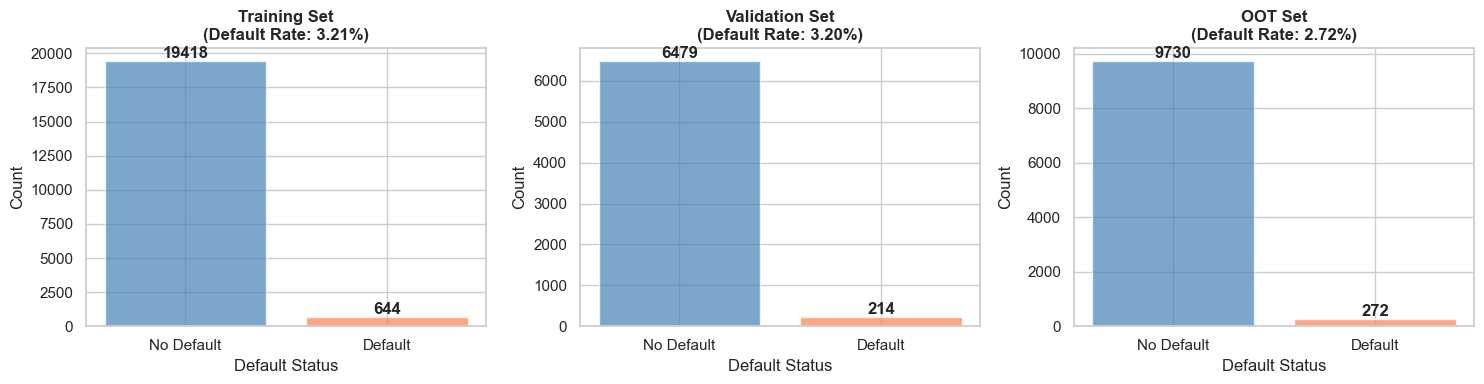

In [ ]:
# Class imbalance analysis 
# Check class distribution in each split
train_counts, train_pct = check_class_distribution(y_train, "X_train")
val_counts, val_pct = check_class_distribution(y_val, X_val)
oot_counts, oot_pct = check_class_distribution(y_oot, X_oot)

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (y, title) in enumerate([(y_train, 'Training'), (y_val, 'Validation'), (y_oot, 'OOT')]):
    counts = y.value_counts().sort_index()
    axes[idx].bar(counts.index, counts.values, color=['steelblue', 'coral'], alpha=0.7)
    axes[idx].set_title(f'{title} Set\n(Default Rate: {y.mean()*100:.2f}%)', fontweight='bold')
    axes[idx].set_xlabel('Default Status')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['No Default', 'Default'])
    
    # Add count labels on bars
    for i, v in enumerate(counts.values):
        axes[idx].text(counts.index[i], v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering

### 3.1 Handle Missing Values


In [14]:
# Identify columns with missing values
# Identify missing columns
missing_value_rules = {
        "fico_score": 99999,
        "income": -1,
        "inq_last_6m": 99 
    }
missing_cols, _ = identify_missing_columns(X_train, missing_value_rules)
print("Columns with missing values:", missing_cols)
print("\nMissing value counts in training set:")
for col in missing_cols:
    if col in X_train.columns:
        X_train_check = X_train.copy()
        if col == 'fico_score':
            X_train_check[col] = X_train_check[col].replace(99999, np.nan)
        elif col == 'inquiries_last_6m':
            X_train_check[col] = X_train_check[col].replace(99, np.nan)
        elif col == 'income':
            X_train_check[col] = X_train_check[col].replace(-1, np.nan)
        missing_count = X_train_check[col].isna().sum()
        missing_pct = (missing_count / len(X_train_check)) * 100
        print(f"  {col}: {missing_count} ({missing_pct:.2f}%)")



Columns with missing values: ['fico_score', 'income', 'inquiries_last_6m']

Missing value counts in training set:
  fico_score: 1002 (4.99%)
  income: 604 (3.01%)
  inquiries_last_6m: 395 (1.97%)


In [20]:
# Replace sentinels with NaN in all datasets
X_train_clean = replace_sentinels(X_train)
X_val_clean = replace_sentinels(X_val)
X_oot_clean = replace_sentinels(X_oot)

In [21]:
# Separate numeric and categorical columns
numeric_cols = X_train_clean.select_dtypes(include = [np.number]).columns.tolist()
categorical_cols = X_train_clean.select_dtypes(include = ["object", "category"]).columns.tolist()
# Identify which numeric and categorical columns have missing values
numeric_missing = [col for col in numeric_cols if col in missing_cols]
categorical_missing = [col for col in categorical_cols if col in missing_cols]

print(f"\nNumeric columns with missing: {numeric_missing}")
print(f"Categorical columns with missing: {categorical_missing}")


Numeric columns with missing: ['fico_score', 'income', 'inquiries_last_6m']
Categorical columns with missing: []


In [22]:
# Create imputers
# Numeric columns: use median
# Categorical columns: use mode 
numeric_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')
# Fit imputers on training data only
if numeric_missing:
    numeric_imputer.fit(X_train_clean[numeric_missing])
if categorical_missing:
    categorical_imputer.fit(X_train_clean[categorical_missing])

# Step 5: Transform all datasets using fitted imputers


# Apply to all datasets
X_train_imputed = impute_missing(X_train_clean, numeric_imputer, categorical_imputer,
                                 numeric_missing, categorical_missing)
X_val_imputed = impute_missing(X_val_clean, numeric_imputer, categorical_imputer,
                               numeric_missing, categorical_missing)
X_oot_imputed = impute_missing(X_oot_clean, numeric_imputer, categorical_imputer,
                               numeric_missing, categorical_missing)

# Verify no missing values remain
print("\nMissing values after imputation:")
print(f"Training: {X_train_imputed.isna().sum().sum()}")
print(f"Validation: {X_val_imputed.isna().sum().sum()}")
print(f"OOT: {X_oot_imputed.isna().sum().sum()}")

# Update X_train, X_val, X_oot for next steps
X_train = X_train_imputed
X_val = X_val_imputed
X_oot = X_oot_imputed


Missing values after imputation:
Training: 0
Validation: 0
OOT: 0


### 3.2 Handle Outliers


In [23]:
from sklearn.preprocessing import RobustScaler

# Strategy: Cap outliers rather than remove them (preserve sample size)
# Fit outlier bounds on training data only
outlier_bounds = {}
numeric_cols_for_outlier = [col for col in numeric_cols if col not in ['term']]  # Exclude discrete counts

for col in numeric_cols_for_outlier:
    if col in X_train.columns:
        lower, upper = detect_outlier_bounds(X_train, col, method='iqr', multiplier=1.5)
        outlier_bounds[col] = {'lower': lower, 'upper': upper}

print("Outlier bounds (fitted on training data):")
for col, bounds in outlier_bounds.items():
    print(f"  {col}: [{bounds['lower']:.2f}, {bounds['upper']:.2f}]")

# Cap outliers in all datasets using training bounds
def cap_outliers(df, bounds_dict):
    """Cap outliers using pre-computed bounds"""
    df_capped = df.copy()
    for col, bounds in bounds_dict.items():
        if col in df_capped.columns:
            df_capped[col] = df_capped[col].clip(lower=bounds['lower'], upper=bounds['upper'])
    return df_capped

X_train_capped = cap_outliers(X_train, outlier_bounds)
X_val_capped = cap_outliers(X_val, outlier_bounds)
X_oot_capped = cap_outliers(X_oot, outlier_bounds)

# Update for next steps
X_train = X_train_capped
X_val = X_val_capped
X_oot = X_oot_capped

print("\nOutlier capping complete. All datasets capped using training data bounds.")


Outlier bounds (fitted on training data):
  fico_score: [413.50, 985.50]
  income: [-24565.38, 130713.62]
  debt_to_income: [-0.21, 1.00]
  num_open_trades: [0.00, 16.00]
  utilization_rate: [-0.18, 1.18]
  inquiries_last_6m: [-2.00, 6.00]
  loan_amount: [-22910.12, 73978.88]
  apr: [-6.83, 30.93]
  employment_length: [-21.00, 59.00]
  age: [-6.50, 101.50]

Outlier capping complete. All datasets capped using training data bounds.


### 3.3 Feature Engineering


In [24]:
fico_bins = [550, 580, 620, 660, 690, 720, 760, 850]
fico_labels = ["550-579", "580-619", "620-659", "660-689", "690-719", "720-759", "760-850"]

X_train = create_fico_bins(X_train, fico_bins, fico_labels)
X_val = create_fico_bins(X_val, fico_bins, fico_labels)
X_oot = create_fico_bins(X_oot, fico_bins, fico_labels)

income_bins = [0, 30000, 60000, 90000, 120000, 150000, 250000, 1000000]
income_labels = ["<30k", "30k-60k", "60k-90k", "90k-120k", "120k-150k", "150k-250k", "250k+"]

def create_income_bins(df, bins, labels):
    """Create income bins"""
    df_binned = df.copy()
    df_binned['income_binned'] = pd.cut(df_binned['income'], 
                                        bins=bins, labels=labels, 
                                        right=False, include_lowest=True)
    return df_binned

X_train = create_income_bins(X_train, income_bins, income_labels)
X_val = create_income_bins(X_val, income_bins, income_labels)
X_oot = create_income_bins(X_oot, income_bins, income_labels)



### 3.4 Encode Categorical Variables


In [25]:
# Identify categorical columns (including newly created bins)
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# Strategy: Use OneHotEncoder for nominal, OrdinalEncoder for ordinal
# Fit encoders on training data only

# For nominal variables (channel, product_type, state)
nominal_cols = ['channel', 'product_type', 'state'] if 'state' in X_train.columns else ['channel', 'product_type']
nominal_cols = [col for col in nominal_cols if col in categorical_cols]

# For ordinal variables (binned features)
ordinal_cols = [col for col in categorical_cols if col not in nominal_cols]

# OneHotEncoder for nominal variables
if nominal_cols:
    onehot_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    onehot_encoder.fit(X_train[nominal_cols])
    
    # Transform all datasets
    train_onehot = onehot_encoder.transform(X_train[nominal_cols])
    val_onehot = onehot_encoder.transform(X_val[nominal_cols])
    oot_onehot = onehot_encoder.transform(X_oot[nominal_cols])
    
    # Create feature names
    onehot_feature_names = onehot_encoder.get_feature_names_out(nominal_cols)
    
    # Create DataFrames
    train_onehot_df = pd.DataFrame(train_onehot, columns=onehot_feature_names, index=X_train.index)
    val_onehot_df = pd.DataFrame(val_onehot, columns=onehot_feature_names, index=X_val.index)
    oot_onehot_df = pd.DataFrame(oot_onehot, columns=onehot_feature_names, index=X_oot.index)
    
    # Drop original columns and add encoded
    X_train = X_train.drop(columns=nominal_cols).join(train_onehot_df)
    X_val = X_val.drop(columns=nominal_cols).join(val_onehot_df)
    X_oot = X_oot.drop(columns=nominal_cols).join(oot_onehot_df)

# OrdinalEncoder for ordinal variables (binned features)
if ordinal_cols:
    ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    ordinal_encoder.fit(X_train[ordinal_cols].values.reshape(-1, len(ordinal_cols)))
    
    # Transform all datasets
    train_ordinal = ordinal_encoder.transform(X_train[ordinal_cols].values.reshape(-1, len(ordinal_cols)))
    val_ordinal = ordinal_encoder.transform(X_val[ordinal_cols].values.reshape(-1, len(ordinal_cols)))
    oot_ordinal = ordinal_encoder.transform(X_oot[ordinal_cols].values.reshape(-1, len(ordinal_cols)))
    
    # Replace original columns
    for i, col in enumerate(ordinal_cols):
        X_train[col] = train_ordinal[:, i]
        X_val[col] = val_ordinal[:, i]
        X_oot[col] = oot_ordinal[:, i]

print("\nCategorical encoding complete.")
print(f"Final feature count: {X_train.shape[1]}")
print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"OOT shape: {X_oot.shape}")



Categorical columns to encode: ['channel', 'product_type', 'state', 'fico_binned', 'income_binned']

Categorical encoding complete.
Final feature count: 25
Training shape: (20062, 25)
Validation shape: (6693, 25)
OOT shape: (10002, 25)


## 4. Model Training

### 4.1 Model 1: Logistic Regression


In [46]:
lr_model = LogisticRegression(class_weight="balanced", random_state = RANDOM_STATE, max_iter = 1000, solver = "lbfgs")
# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_oot_scaled = scaler.transform(X_oot)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_proba = lr_model.predict_proba(X_train_scaled)[:, 1]
y_val_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
y_oot_pred_proba = lr_model.predict_proba(X_oot_scaled)[:, 1]

# Predictions with default threshold (0.5)
y_train_pred = lr_model.predict(X_train_scaled)
y_val_pred = lr_model.predict(X_val_scaled)
y_oot_pred = lr_model.predict(X_oot_scaled)

print("Logistic Regression (with class_weight='balanced')")
print("="*60)
print(f"Training AUC-ROC: {roc_auc_score(y_train, y_train_pred_proba):.4f}")
print(f"Validation AUC-ROC: {roc_auc_score(y_val, y_val_pred_proba):.4f}")
print(f"OOT AUC-ROC: {roc_auc_score(y_oot, y_oot_pred_proba):.4f}")

Logistic Regression (with class_weight='balanced')
Training AUC-ROC: 0.6743
Validation AUC-ROC: 0.6730
OOT AUC-ROC: 0.6566


In [ ]:
evaluate_binary_model(y_train, y_train_pred_proba, "Train")
evaluate_binary_model(y_val, y_val_pred_proba, "Validation")
evaluate_binary_model(y_oot, y_oot_pred_proba, "OOT")


Train
----------------------------------------
AUC-ROC      : 0.6743
PR AUC       : 0.0595
KS Statistic : 0.2532

Validation
----------------------------------------
AUC-ROC      : 0.6730
PR AUC       : 0.0612
KS Statistic : 0.2807

OOT
----------------------------------------
AUC-ROC      : 0.6566
PR AUC       : 0.0488
KS Statistic : 0.2365



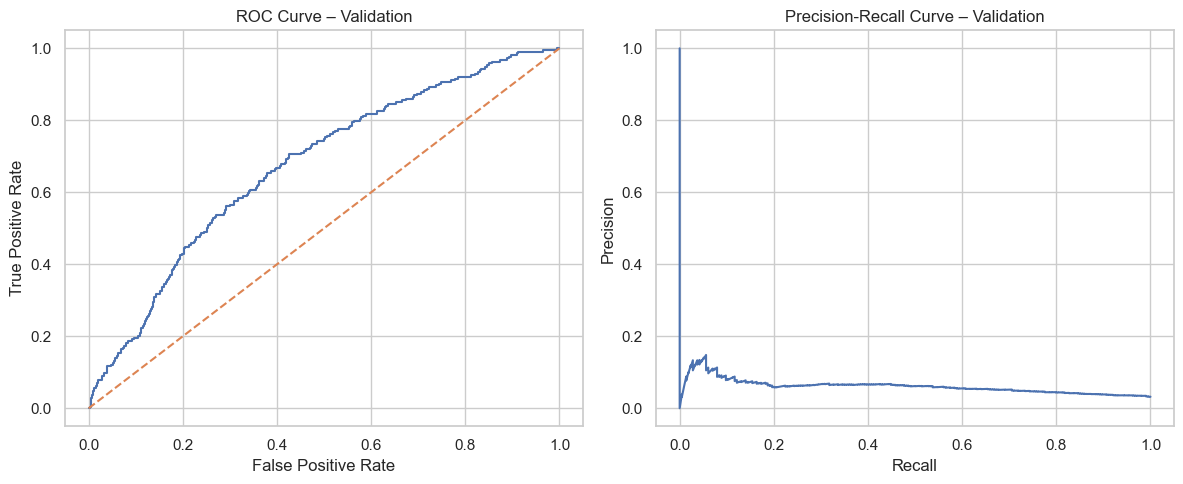

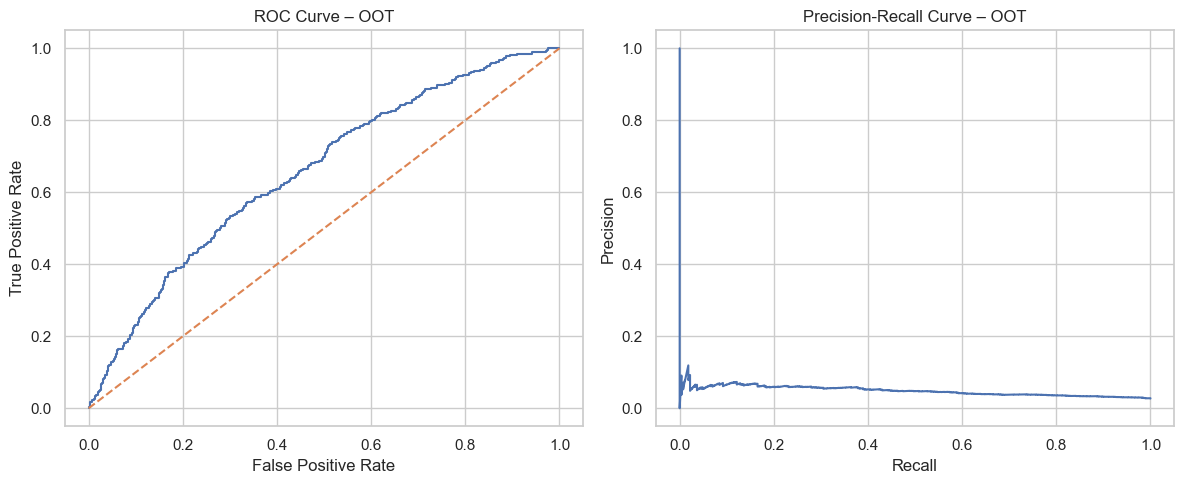

In [ ]:
plot_roc_pr(y_val, y_val_pred_proba, "Validation")
plot_roc_pr(y_oot, y_oot_pred_proba, "OOT")


In [ ]:
best_threshold, best_f1 = find_best_threshold(y_val, y_val_pred_proba)
print(f"Best threshold (Val): {best_threshold:.4f}")
print(f"Best F1 (Val): {best_f1:.4f}")


Best threshold (Val): 0.5832
Best F1 (Val): 0.1174


In [ ]:

evaluate_at_threshold(y_val, y_val_pred_proba, best_threshold)
evaluate_at_threshold(y_oot, y_oot_pred_proba, best_threshold)


Confusion Matrix
[[5153 1326]
 [ 118   96]]

Classification Report
              precision    recall  f1-score   support

           0     0.9776    0.7953    0.8771      6479
           1     0.0675    0.4486    0.1174       214

    accuracy                         0.7843      6693
   macro avg     0.5226    0.6220    0.4972      6693
weighted avg     0.9485    0.7843    0.8528      6693

Confusion Matrix
[[7547 2183]
 [ 155  117]]

Classification Report
              precision    recall  f1-score   support

           0     0.9799    0.7756    0.8659      9730
           1     0.0509    0.4301    0.0910       272

    accuracy                         0.7662     10002
   macro avg     0.5154    0.6029    0.4784     10002
weighted avg     0.9546    0.7662    0.8448     10002



In [ ]:


ks_val, ks_thr_val = ks_with_threshold(y_val, y_val_pred_proba)
print(f"Validation KS={ks_val:.3f} at threshold={ks_thr_val:.3f}")
ks_oot, ks_thr_oot = ks_with_threshold(y_oot, y_oot_pred_proba)
print(f"OOT KS={ks_oot:.3f} at threshold={ks_thr_oot:.3f}")


Validation KS=0.281 at threshold=0.474
OOT KS=0.237 at threshold=0.523


This is a reasonable benchmark logistic, correctly built, correctly validated, and correctly diagnosed.
It is not sufficient for production decisions without:
non-linear modeling
interaction handling
monotonic constraints
better threshold policy

### 4.2 Model 2: Gradient Boosting / XGBoost / LightGBM


In [53]:
import xgboost as xgb

In [54]:
# calculate class weights for XGBoost
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count 
print("XGBoost Class Weight Configuration:")
print("="*60)
print(f"Negative samples (Class 0): {negative_count}")
print(f"Positive samples (Class 1): {positive_count}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")
print(f"This means positive class will be weighted {scale_pos_weight:.2f}x more")
print()

XGBoost Class Weight Configuration:
Negative samples (Class 0): 19418
Positive samples (Class 1): 644
scale_pos_weight: 30.1522
This means positive class will be weighted 30.15x more



In [ ]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes = classes, y = y_train)
class_weight_dict = dict(zip(classes, class_weights))
sample_weights = np.array([class_weight_dict[y] for y in y_train])
print("Alternative: Sample Weights")
print("="*60)
print(f"Class 0 weight: {class_weight_dict[0]:.4f}")
print(f"Class 1 weight: {class_weight_dict[1]:.4f}")
print()

Alternative: Sample Weights
Class 0 weight: 0.5166
Class 1 weight: 15.5761



In [56]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
doot   = xgb.DMatrix(X_oot)
params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "max_depth": 4,
    "min_child_weight": 5,
    "gamma": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.5,
    "reg_lambda": 1.0,
    "learning_rate": 0.05,
    "scale_pos_weight": scale_pos_weight,
    "seed": RANDOM_STATE,
    "nthread": -1
}
evals = [(dtrain, "train"), (dval, "val")]

xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=200,
    evals=evals,
    early_stopping_rounds=30,
    verbose_eval=True
)

# Predictions
y_train_pred_proba_xgb = xgb_model.predict(dtrain)
y_val_pred_proba_xgb   = xgb_model.predict(dval)
y_oot_pred_proba_xgb   = xgb_model.predict(doot)

# Predictions with default threshold (0.5)
y_train_pred_xgb = (y_train_pred_proba_xgb >= 0.5).astype(int)
y_val_pred_xgb   = (y_val_pred_proba_xgb   >= 0.5).astype(int)
y_oot_pred_xgb   = (y_oot_pred_proba_xgb   >= 0.5).astype(int)

print("\nXGBoost Model Performance (with scale_pos_weight):")
print("="*60)
print(f"Training AUC-ROC: {roc_auc_score(y_train, y_train_pred_proba_xgb):.4f}")
print(f"Validation AUC-ROC: {roc_auc_score(y_val, y_val_pred_proba_xgb):.4f}")
print(f"OOT AUC-ROC: {roc_auc_score(y_oot, y_oot_pred_proba_xgb):.4f}")
print()
print(f"Training Precision: {precision_score(y_train, y_train_pred_xgb):.4f}")
print(f"Training Recall: {recall_score(y_train, y_train_pred_xgb):.4f}")
print(f"Training F1-Score: {f1_score(y_train, y_train_pred_xgb):.4f}")
print()
print(f"Validation Precision: {precision_score(y_val, y_val_pred_xgb):.4f}")
print(f"Validation Recall: {recall_score(y_val, y_val_pred_xgb):.4f}")
print(f"Validation F1-Score: {f1_score(y_val, y_val_pred_xgb):.4f}")

[0]	train-auc:0.72177	val-auc:0.67141
[1]	train-auc:0.73017	val-auc:0.68330
[2]	train-auc:0.74277	val-auc:0.69363
[3]	train-auc:0.75375	val-auc:0.69504
[4]	train-auc:0.75823	val-auc:0.69710
[5]	train-auc:0.75841	val-auc:0.69508
[6]	train-auc:0.75971	val-auc:0.69696
[7]	train-auc:0.76292	val-auc:0.70183
[8]	train-auc:0.76299	val-auc:0.69624
[9]	train-auc:0.76576	val-auc:0.69748
[10]	train-auc:0.76624	val-auc:0.69770
[11]	train-auc:0.76822	val-auc:0.69606
[12]	train-auc:0.76789	val-auc:0.69558
[13]	train-auc:0.77010	val-auc:0.69474
[14]	train-auc:0.77238	val-auc:0.69322
[15]	train-auc:0.77270	val-auc:0.69398
[16]	train-auc:0.77420	val-auc:0.69382
[17]	train-auc:0.77577	val-auc:0.69358
[18]	train-auc:0.77626	val-auc:0.69292
[19]	train-auc:0.77821	val-auc:0.69204
[20]	train-auc:0.77924	val-auc:0.69149
[21]	train-auc:0.78097	val-auc:0.69083
[22]	train-auc:0.78151	val-auc:0.68919
[23]	train-auc:0.78232	val-auc:0.69035
[24]	train-auc:0.78322	val-auc:0.69039
[25]	train-auc:0.78424	val-auc:0.69

In [57]:
# Fine tune the model
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [3, 4],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 0.5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 400, 600],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

base_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric="auc",
    use_label_encoder=False,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best AUC (CV):", search.best_score_)
print("Best Params:", search.best_params_)
y_val_proba = best_model.predict_proba(X_val)[:, 1]
y_oot_proba = best_model.predict_proba(X_oot)[:, 1]

print("Validation AUC:", roc_auc_score(y_val, y_val_proba))
print("Validation KS:", ks_statistic(y_val, y_val_proba))
print("OOT AUC:", roc_auc_score(y_oot, y_oot_proba))
print("OOT KS:", ks_statistic(y_oot, y_oot_proba))


Fitting 3 folds for each of 30 candidates, totalling 90 fits


/Users/wei/miniforge3/envs/nlp_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/wei/miniforge3/envs/nlp_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/wei/miniforge3/envs/nlp_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from usi

Best AUC (CV): nan
Best Params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}
Validation AUC: 0.7005483568048029
Validation KS: 0.3185849898954638
OOT AUC: 0.6910419563508857
OOT KS: 0.3173644277855027


In [ ]:
ks_threshold, ks_value = find_best_ks_threshold(y_val, y_val_proba)

print(f"Best KS Threshold: {ks_threshold:.4f}")
print(f"KS at Threshold: {ks_value:.4f}")


Best KS Threshold: 0.4942
KS at Threshold: 0.3186


In [59]:
final_threshold = ks_threshold 

y_oot_pred = (best_model.predict_proba(X_oot)[:, 1] >= final_threshold)

print("Final OOT Performance")
print("=" * 40)
print("Precision:", precision_score(y_oot, y_oot_pred))
print("Recall:", recall_score(y_oot, y_oot_pred))
print("F1:", f1_score(y_oot, y_oot_pred))

Final OOT Performance
Precision: 0.04612925325416762
Recall: 0.7426470588235294
F1: 0.08686304020640723


## 5. Model Evaluation & Comparison

### 5.1 Calculate Metrics (AUC, KS, Precision-Recall)


In [ ]:
# Get optimal thresholds (from your previous code)
# Logistic Regression optimal threshold (from validation)
lr_best_threshold = best_threshold  # From your find_best_threshold function

# XGBoost optimal threshold (from validation)
xgb_best_threshold = ks_threshold  # From your find_best_ks_threshold function

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# Calculate metrics for Logistic Regression
lr_metrics = []

# Training set
lr_train_pred_opt = (y_train_pred_proba >= lr_best_threshold).astype(int)
lr_metrics.append(calculate_all_metrics(y_train, y_train_pred_proba, lr_train_pred_opt, 'Train', 'Logistic Regression'))

# Validation set
lr_val_pred_opt = (y_val_pred_proba >= lr_best_threshold).astype(int)
lr_metrics.append(calculate_all_metrics(y_val, y_val_pred_proba, lr_val_pred_opt, 'Validation', 'Logistic Regression'))

# OOT set
lr_oot_pred_opt = (y_oot_pred_proba >= lr_best_threshold).astype(int)
lr_metrics.append(calculate_all_metrics(y_oot, y_oot_pred_proba, lr_oot_pred_opt, 'OOT', 'Logistic Regression'))

# Calculate metrics for XGBoost
xgb_metrics = []

# Training set
y_train_proba_xgb = best_model.predict_proba(X_train)[:, 1]
xgb_train_pred_opt = (y_train_proba_xgb >= xgb_best_threshold).astype(int)
xgb_metrics.append(calculate_all_metrics(y_train, y_train_proba_xgb, xgb_train_pred_opt, 'Train', 'XGBoost'))

# Validation set
y_val_proba_xgb   = best_model.predict_proba(X_val)[:, 1]
xgb_val_pred_opt   = (y_val_proba_xgb   >= xgb_best_threshold).astype(int)
xgb_metrics.append(calculate_all_metrics(y_val, y_val_proba_xgb, xgb_val_pred_opt, 'Validation', 'XGBoost'))

# OOT set
y_oot_proba_xgb   = best_model.predict_proba(X_oot)[:, 1]
xgb_oot_pred_opt   = (y_oot_proba_xgb   >= xgb_best_threshold).astype(int)
xgb_metrics.append(calculate_all_metrics(y_oot, y_oot_proba_xgb, xgb_oot_pred_opt, 'OOT', 'XGBoost'))

# Create comparison DataFrame
comparison_df = pd.DataFrame(lr_metrics + xgb_metrics)
comparison_df = comparison_df.round(4)

print("\nModel Comparison Table (Using Optimal Thresholds):")
print("="*80)
print(comparison_df.to_string(index=False))

# Summary comparison by dataset
print("\n" + "="*80)
print("SUMMARY COMPARISON BY DATASET")
print("="*80)

for dataset in ['Train', 'Validation', 'OOT']:
    print(f"\n{dataset} Set:")
    print("-" * 60)
    dataset_df = comparison_df[comparison_df['Dataset'] == dataset]
    
    print(f"  AUC-ROC:")
    print(f"    Logistic Regression: {dataset_df[dataset_df['Model']=='Logistic Regression']['AUC-ROC'].values[0]:.4f}")
    print(f"    XGBoost:             {dataset_df[dataset_df['Model']=='XGBoost']['AUC-ROC'].values[0]:.4f}")
    
    print(f"\n  KS Statistic:")
    print(f"    Logistic Regression: {dataset_df[dataset_df['Model']=='Logistic Regression']['KS'].values[0]:.4f}")
    print(f"    XGBoost:             {dataset_df[dataset_df['Model']=='XGBoost']['KS'].values[0]:.4f}")
    
    print(f"\n  PR-AUC:")
    print(f"    Logistic Regression: {dataset_df[dataset_df['Model']=='Logistic Regression']['PR-AUC'].values[0]:.4f}")
    print(f"    XGBoost:             {dataset_df[dataset_df['Model']=='XGBoost']['PR-AUC'].values[0]:.4f}")
    
    print(f"\n  F1-Score:")
    print(f"    Logistic Regression: {dataset_df[dataset_df['Model']=='Logistic Regression']['F1-Score'].values[0]:.4f}")
    print(f"    XGBoost:             {dataset_df[dataset_df['Model']=='XGBoost']['F1-Score'].values[0]:.4f}")

print("\n" + "="*80)
print(f"Optimal Thresholds:")
print(f"  Logistic Regression: {lr_best_threshold:.4f}")
print(f"  XGBoost:             {xgb_best_threshold:.4f}")
print("="*80)

COMPREHENSIVE MODEL COMPARISON

Model Comparison Table (Using Optimal Thresholds):
              Model    Dataset  AUC-ROC  PR-AUC     KS  Precision  Recall  F1-Score
Logistic Regression      Train   0.6743  0.0595 0.2532     0.0574  0.4037    0.1005
Logistic Regression Validation   0.6730  0.0612 0.2807     0.0675  0.4486    0.1174
Logistic Regression        OOT   0.6566  0.0488 0.2365     0.0509  0.4301    0.0910
            XGBoost      Train   0.7589  0.1033 0.3823     0.0585  0.8028    0.1090
            XGBoost Validation   0.7005  0.0655 0.3186     0.0544  0.7477    0.1015
            XGBoost        OOT   0.6910  0.0536 0.3174     0.0461  0.7426    0.0869

SUMMARY COMPARISON BY DATASET

Train Set:
------------------------------------------------------------
  AUC-ROC:
    Logistic Regression: 0.6743
    XGBoost:             0.7589

  KS Statistic:
    Logistic Regression: 0.2532
    XGBoost:             0.3823

  PR-AUC:
    Logistic Regression: 0.0595
    XGBoost:             0

### 5.2 ROC Curves


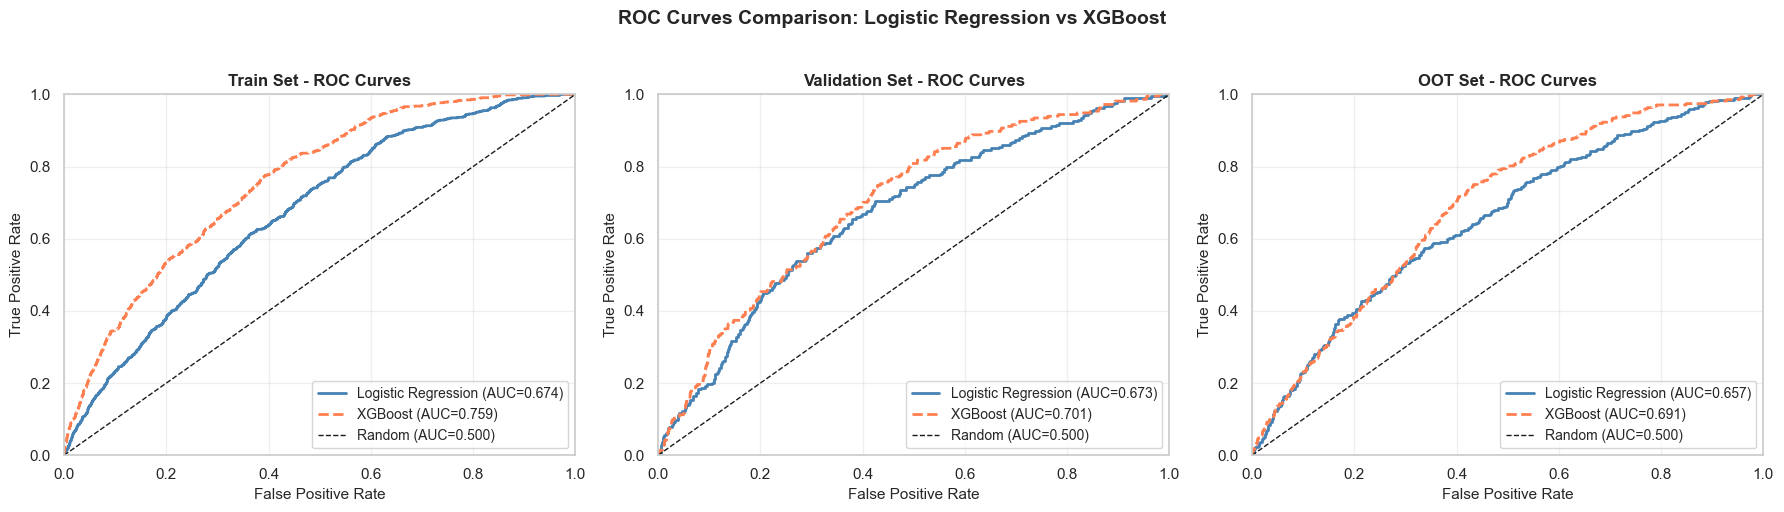

In [61]:
### 5.2 ROC Curves

# Plot ROC curves for both models side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ('Train', y_train, y_train_pred_proba, best_model.predict_proba(X_train)[:,1]),
    ('Validation', y_val, y_val_pred_proba, best_model.predict_proba(X_val)[:,1]),
    ('OOT', y_oot, y_oot_pred_proba, best_model.predict_proba(X_oot)[:,1])
]


for idx, (name, y_true, lr_proba, xgb_proba) in enumerate(datasets):
    ax = axes[idx]
    
    # Logistic Regression ROC
    fpr_lr, tpr_lr, _ = roc_curve(y_true, lr_proba)
    auc_lr = roc_auc_score(y_true, lr_proba)
    ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', 
            linewidth=2, color='steelblue')
    
    # XGBoost ROC
    fpr_xgb, tpr_xgb, _ = roc_curve(y_true, xgb_proba)
    auc_xgb = roc_auc_score(y_true, xgb_proba)
    ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})', 
            linewidth=2, color='coral', linestyle='--')
    
    # Random baseline
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
    
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{name} Set - ROC Curves', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('ROC Curves Comparison: Logistic Regression vs XGBoost', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### 5.3 Precision-Recall Curves


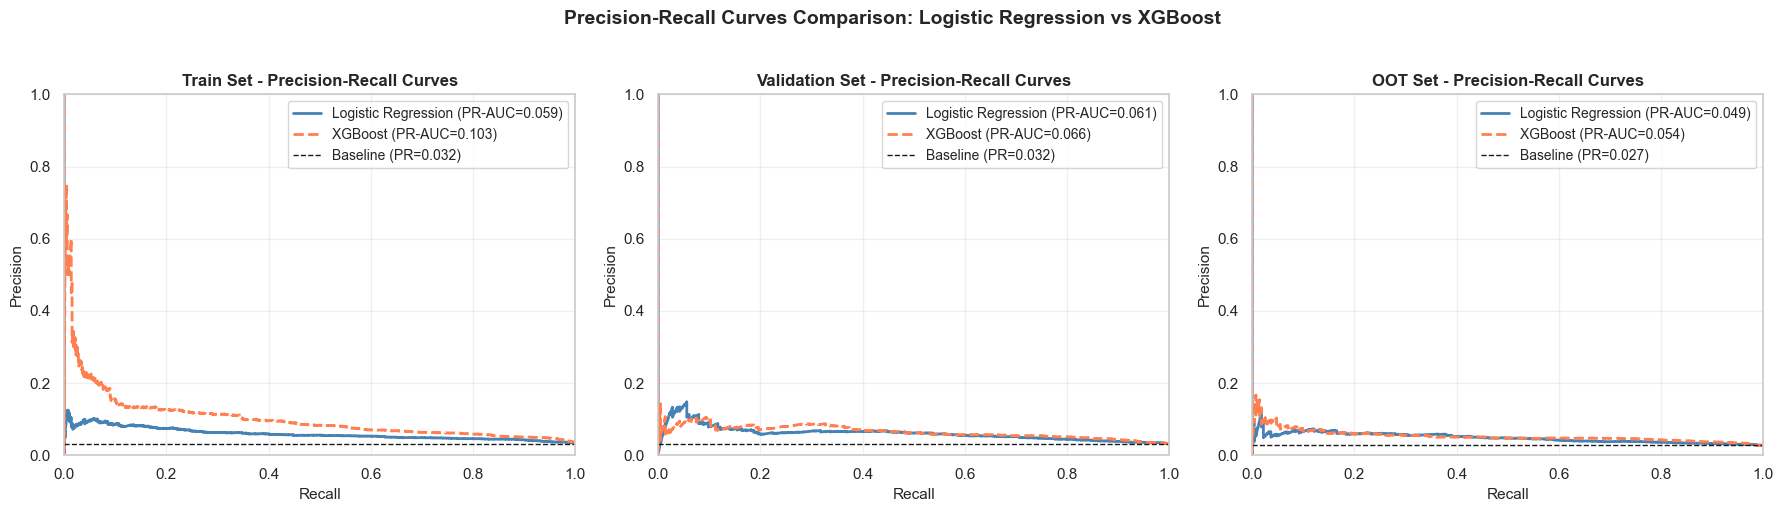

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_true, lr_proba, xgb_proba) in enumerate(datasets):
    ax = axes[idx]
    
    # Logistic Regression PR
    precision_lr, recall_lr, _ = precision_recall_curve(y_true, lr_proba)
    pr_auc_lr = average_precision_score(y_true, lr_proba)
    ax.plot(recall_lr, precision_lr, label=f'Logistic Regression (PR-AUC={pr_auc_lr:.3f})', 
            linewidth=2, color='steelblue')
    
    # XGBoost PR
    precision_xgb, recall_xgb, _ = precision_recall_curve(y_true, xgb_proba)
    pr_auc_xgb = average_precision_score(y_true, xgb_proba)
    ax.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR-AUC={pr_auc_xgb:.3f})', 
            linewidth=2, color='coral', linestyle='--')
    
    # Baseline (random classifier)
    baseline = y_true.mean()
    ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline (PR={baseline:.3f})')
    
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'{name} Set - Precision-Recall Curves', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Precision-Recall Curves Comparison: Logistic Regression vs XGBoost', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

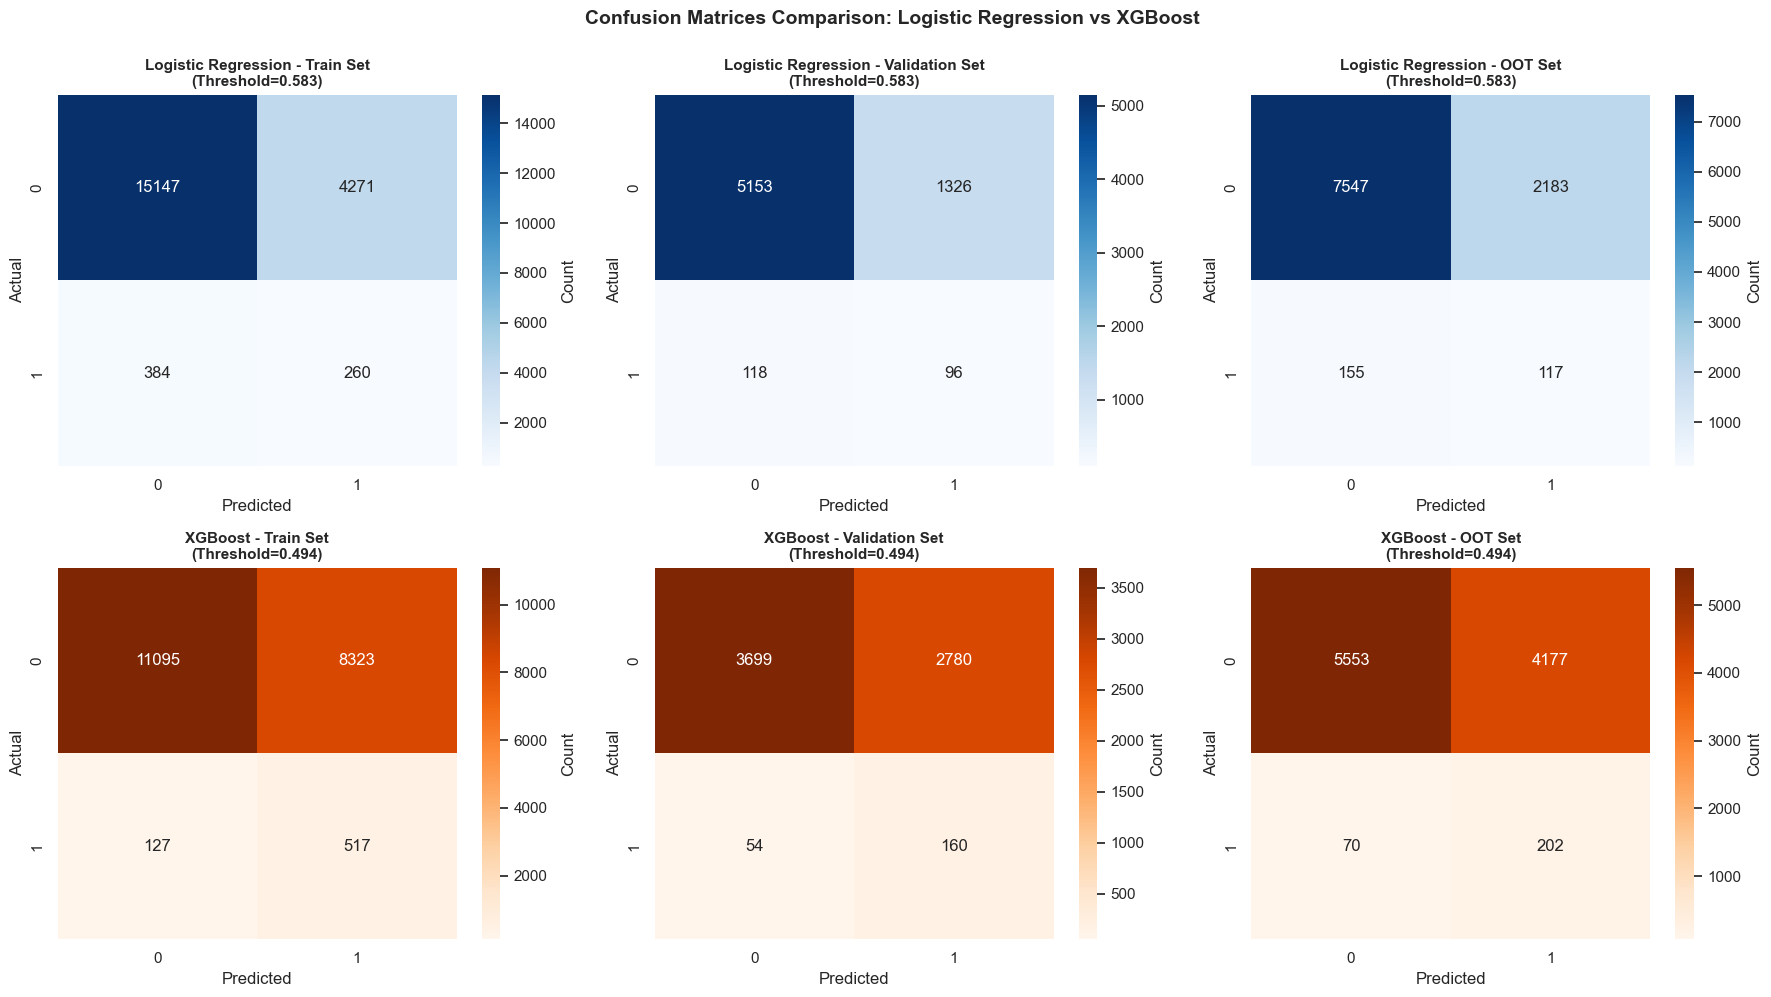

In [63]:
# Plot precision-recall curves
### 5.4 Confusion Matrices Comparison

# Plot confusion matrices for both models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (name, y_true, lr_proba, xgb_proba) in enumerate(datasets):
    # Logistic Regression confusion matrix
    lr_pred = (lr_proba >= lr_best_threshold).astype(int)
    cm_lr = confusion_matrix(y_true, lr_pred)
    
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0, col_idx],
                cbar_kws={'label': 'Count'})
    axes[0, col_idx].set_title(f'Logistic Regression - {name} Set\n(Threshold={lr_best_threshold:.3f})', 
                               fontsize=11, fontweight='bold')
    axes[0, col_idx].set_xlabel('Predicted')
    axes[0, col_idx].set_ylabel('Actual')
    
    # XGBoost confusion matrix
    xgb_pred = (xgb_proba >= xgb_best_threshold).astype(int)
    cm_xgb = confusion_matrix(y_true, xgb_pred)
    
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1, col_idx],
                cbar_kws={'label': 'Count'})
    axes[1, col_idx].set_title(f'XGBoost - {name} Set\n(Threshold={xgb_best_threshold:.3f})', 
                               fontsize=11, fontweight='bold')
    axes[1, col_idx].set_xlabel('Predicted')
    axes[1, col_idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices Comparison: Logistic Regression vs XGBoost', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 6. Model Interpretation

### 6.1 Feature Importance


In [64]:
import shap

Calculating SHAP values for Logistic Regression

Top 20 Features by SHAP Importance (Logistic Regression):
                        feature  shap_importance
                 debt_to_income         0.307978
                     fico_score         0.281655
                    fico_binned         0.139445
                         income         0.117841
                  income_binned         0.099965
               utilization_rate         0.091678
              inquiries_last_6m         0.059421
  product_type_Home_Improvement         0.057826
                       state_TX         0.057230
                            apr         0.052409
                           term         0.044573
          product_type_Personal         0.043762
                            age         0.035260
                channel_Partner         0.030001
                       state_FL         0.025245
              employment_length         0.020306
                   channel_Mail         0.019269
          p

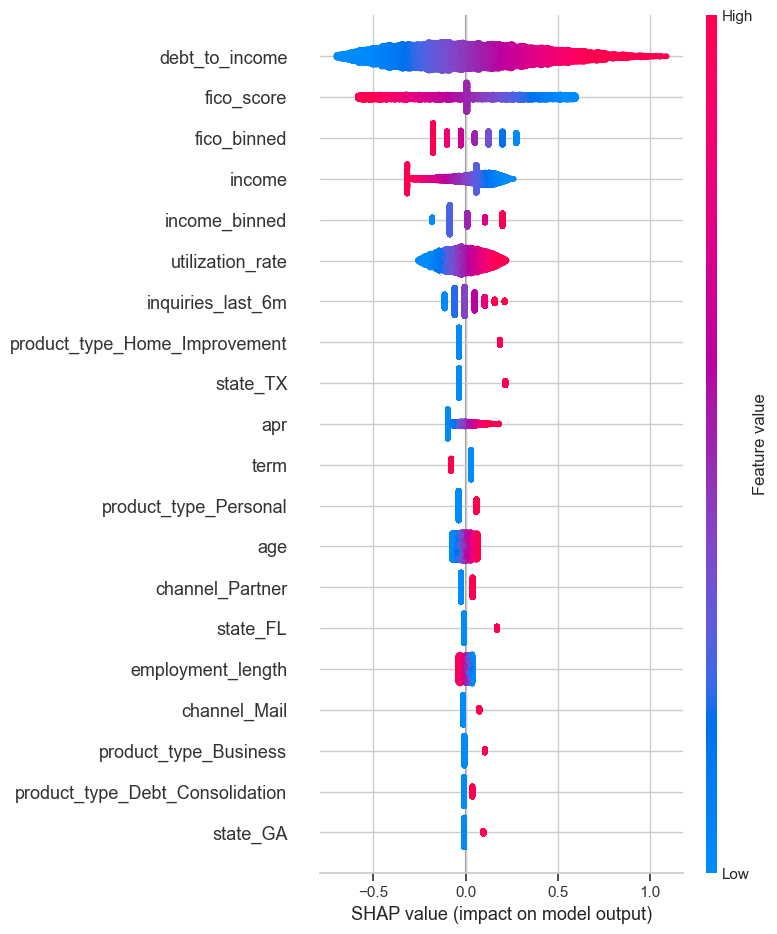

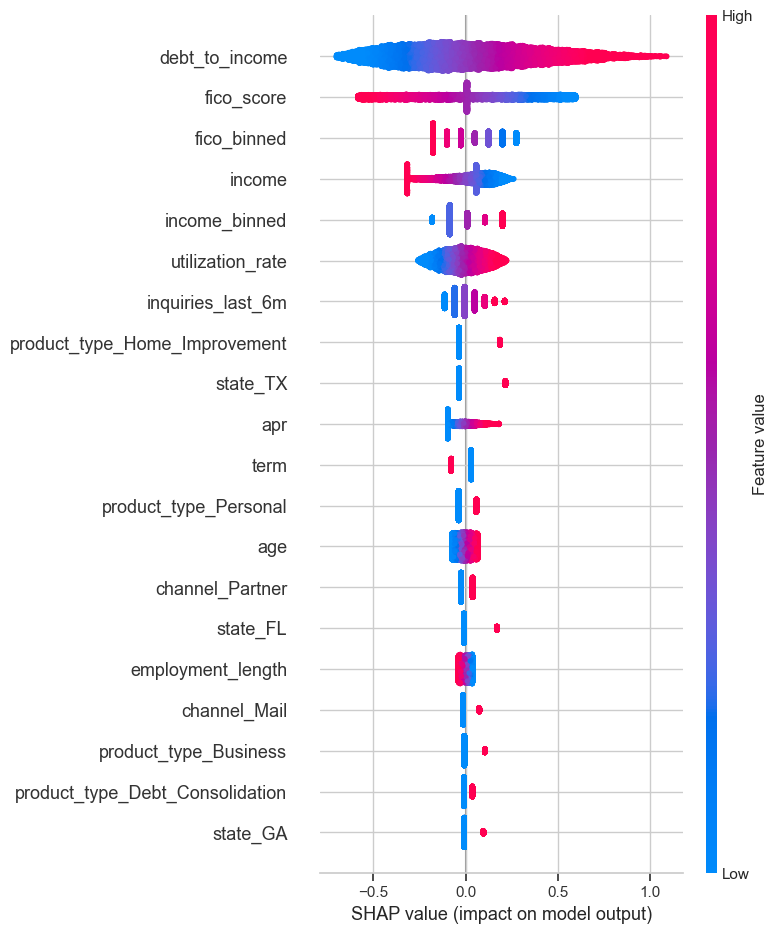

In [84]:
# Get feature names from training data
feature_names = X_train.columns.tolist()
# For linear models, use LinearExplainer (faster) or KernelExplainer
# LinearExplainer is exact for linear models
print("Calculating SHAP values for Logistic Regression")
lr_explainer = shap.LinearExplainer(lr_model, X_train_scaled, feature_perturbation="interventional")
lr_shap_values = lr_explainer.shap_values(X_train_scaled)

# If binary classification, get positive class
if isinstance(lr_shap_values, list):
    lr_shap_values = lr_shap_values[1]

# Mean absolute SHAP for ranking
lr_shap_importance = pd.DataFrame({
    'feature': X_train.columns,
    'shap_importance': np.abs(lr_shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("\nTop 20 Features by SHAP Importance (Logistic Regression):")
print(lr_shap_importance.head(20).to_string(index=False))

# -----------------------------
# Logistic Regression Plots
# -----------------------------
shap.summary_plot(lr_shap_values, X_train_scaled, feature_names=X_train.columns, plot_type="dot")
shap.summary_plot(lr_shap_values, X_train_scaled, feature_names=X_train.columns)

Calculating SHAP values for XGBoost

Top 20 features by mean absolute SHAP value:
                            feature  shap_importance
0                        fico_score         0.478162
2                    debt_to_income         0.342542
1                            income         0.099231
4                  utilization_rate         0.062746
12                    income_binned         0.022987
8                               apr         0.018247
3                   num_open_trades         0.011745
6                       loan_amount         0.010108
9                 employment_length         0.008580
10                              age         0.006601
5                 inquiries_last_6m         0.004913
7                              term         0.002621
21                         state_IL         0.001398
14                  channel_Partner         0.001280
23                      state_Other         0.000920
15            product_type_Business         0.000878
16  product_type_

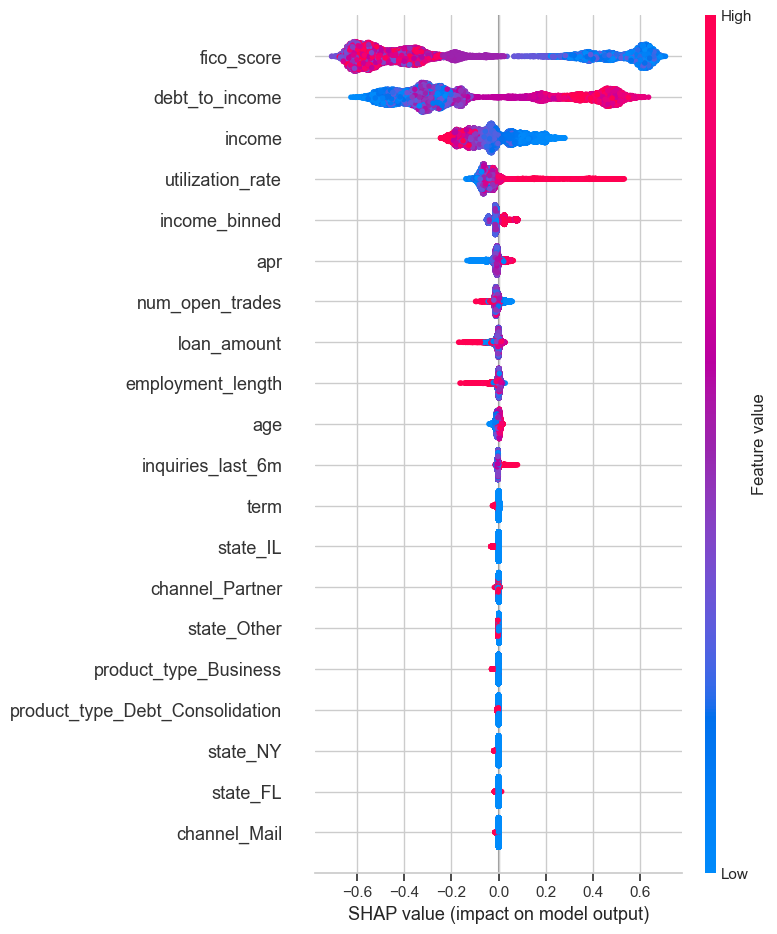

In [85]:
print("Calculating SHAP values for XGBoost")
explainer = shap.TreeExplainer(best_model)

# You can use training set or a subset if it's large
xgb_shap_values = explainer.shap_values(X_train)

# For binary classification, shap_values may be a list
if isinstance(xgb_shap_values, list):
    xgb_shap_values = xgb_shap_values[1]  # Use positive class (default=1)

# -----------------------------
# 2. Aggregate SHAP importance
# -----------------------------
xgb_shap_importance = pd.DataFrame({
    "feature": X_train.columns,
    "shap_importance": np.abs(xgb_shap_values).mean(axis=0)
}).sort_values("shap_importance", ascending=False)

print("\nTop 20 features by mean absolute SHAP value:")
print(xgb_shap_importance.head(20))

# -----------------------------
# 3. Plot summary plot (beeswarm)
# -----------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(xgb_shap_values, X_train, plot_type="dot", show=True)


### 6.2 Key Drivers of Default


In [79]:
direction_xgb = feature_direction(xgb_shap_values, X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
direction_lr = feature_direction(lr_shap_values, X_train_scaled_df)

In [82]:
direction_xgb.head()

,feature,mean_shap,direction
0,fico_score,-0.147853,decrease_risk
2,debt_to_income,-0.102162,decrease_risk
1,income,-0.026407,decrease_risk
4,utilization_rate,-0.022758,decrease_risk
8,apr,-0.007460,decrease_risk


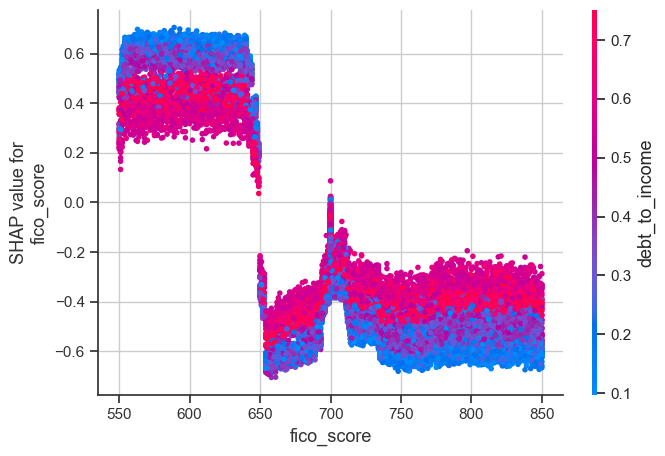

In [ ]:

top_xgb_features = summarize_shap(xgb_shap_values, X_train, top_n=10)
top_lr_features = summarize_shap(lr_shap_values, X_train_scaled_df, top_n=10)
plot_dependence_feature(xgb_shap_values, X_train, top_xgb_features['feature'].iloc[0])

## 7. Discussion & Next Steps

### 7.1 Model Assumptions

TODO: Discuss assumptions made by your models:
- Logistic Regression assumptions (linearity, independence, etc.)
- Tree-based model assumptions
- Any data assumptions

### 7.2 Potential Data Leakage

TODO: Discuss potential sources of data leakage:
- Features that might contain information about the target
- Temporal considerations
- Other leakage risks

### 7.3 Model Improvements

TODO: Discuss how you would improve model performance:
- Additional feature engineering
- Hyperparameter tuning
- Ensemble methods
- External data sources
- Handling class imbalance

### 7.4 Production Considerations

TODO: Discuss production deployment considerations:
- Model monitoring
- Performance degradation
- Scalability
- Interpretability requirements
- Regulatory compliance

---

## Summary

TODO: Provide a brief summary of your findings:
- Best performing model and why
- Key insights about default risk
- Recommendations for deployment

---


7.1 Model assumptions
- Logistic regression assumption:
    - Independent of errors, the model assumes that the observations are not related to one another
    - Linearity in the logit, assumes a linear relationship between the log-odds of default and the input features.
    - No multicollinearity, high correlation between features may distort the estimated effect of individual predictors.  
    - Enough sample size
- XGBoost Classifier assumption 
    - No linearity/Monotonicity required
    - Feature Independence, XGBoost is very robust to multicollinearity (feature dependence) 
    - Stable Distribution
    - Missing values: XGBoos assumes missing data is informative. 
- Data assumption
    - Assumes the training, validation, and OOT datasets come from the same underlying distribution
    - Assumes that categorical encoding and scaling are consistent across datasets
    - Assumes target variable labeling is accurate
    - Consistency

7.2 Potential Data Leakage

The potential sources of data leakage:
- Time leakage
- Label leakage. 
- Group/ID leakage. If the data has multiple rows per customer, a random split might put a customer's Monday data in Train and their Tuesday data in Test. The model memorizes the person rather than learning the behavior. 
- Aggregation leakage. If calcualte the mean or std of a feature across the entire dataset before splitting, the training set will know the distribution of the test set. 
- Random split leakage
- Features that might contain information about the target
- Temporal considerations: in credit/fraud, must use a time-series split/ out of time validation. If use a random split, the model might predict the past using the future 

7.3 Model improvements
- Feature engineering
    - XGBoost: It handles non-linearities well, but it cannot see ratios. Creating features like debt_to_income_ratio manually often gives a bigger boost than tuning
    - Logistic regression: Must handle outliters and binning for variables that have a U-shaped relationiship with the target. 
    - Create interaction features
    - Use non-linear transformations for skewed variables
    - Aggregate historical behavior features
- Hyperparameter tuning
    - XGBoost: further fine-tune max_depth, min_child_weight, subsample and colsample_bytree, gamma
    - Logistic regression: tune regularization strength and consider penalty type
- Ensemble methods
    - Blend logistic regression, XGBoost, and possibly other options to capture complementary patterns
- External data sources
    - Credit bureau sources, more economic variables 
- Handling class imbalance
    - Increase data size
    - Algorithm-level weights
    - Threshold tuning 

7.4 Porduction Considerations
- Model monitoring
    - Feature drift: monitoring if the distribution of incoming features has changed compared to the training data
    - Concept drift: monitoring if the relationship between features and the target has changed
    - Metric decay: tracking real-time performance using metrics like KS, AUC-ORC
- Performance degradation
- Scalability
    - Batch scoring, scalability is about handling large volumnes of data in a data warehouse
    - Real-time API, scalability is about latency. Must ensure the feature engineering happens in milliseconds
    - Resource management. Need to ensure the production environment has the memory to load the model object
- Interpretability requirements 
    - Global interpretability: understanding which features are most important overall
    - Local interpretability:
        - Logistic regression: use the coefficients
        - Use SHAP values to explain exactly why that specific individual features
- Regulatory compliance
    - Adverse action notice: legally required to tell a consumer why they received that result
    - Bias & Fairness: must test the model for disparate impact
    - Model lineage: Must be able to time travel

Summary:
- Best performaing model:
    - XGBoost with tuned hyperparameters and KS optimized threshold
    - Achieved higher AUC-ROC and PR-AUC on validation and OOT, capturing non-linear effects and interactions that Logistic Regression could not
- Key driver of default risk 
    - FICO score is the most important driver, lower FICO means higher risk
    - Debt-to-income ratio is the second strongest driver, higher ratio means higher risk
    - Income and utilization_rate ratio also contribute but less then top 2
    - State, channel, product_type have minimal impact, suggesting demographic/geographic features are secondary
- Recommendations for deployment
    - Save the fine-tuned XGBoost and apply the optimized KS threshold for scoring
    - Use SHAP-based monitoring to track shifts in key drivers over time
    - Consider adding periodic re-training as feature distributions evolve
    - Document model assumptions, key drivers, and thresholds for internal and regulatory review